# 13차시: 회귀 모델의 확장 - 다항회귀와 로지스틱 회귀

---

## 학습 목표

1. **다항회귀(Polynomial Regression)** 로 비선형 관계를 모델링함
2. **분류 문제와 예측 문제의 차이** 를 명확히 구분함
3. **로지스틱 회귀(Logistic Regression)** 로 이진 분류 모델을 생성하고 해석함
4. 실제 제조 데이터에서 전처리의 중요성과 모델 평가 방법을 이해함

---

## 실습 데이터셋

| 데이터셋 | 출처 | 용도 | 특징 |
|:---------|:-----|:-----|:-----|
| **Concrete Compressive Strength** | UCI ML Repository | 다항회귀 실습 | 콘크리트 제조, 원료 배합 vs 강도 (1,030건) |
| **Steel Plates Faults** | UCI ML Repository | 로지스틱 회귀 실습 | 철강 제조, 결함 분류 7종 (1,941건) |

# 1: 다항회귀 (Polynomial Regression)

## 1.1 선형회귀의 한계와 다항회귀의 필요성

### 왜 다항회귀가 필요한가?

선형회귀는 독립변수 $X$와 종속변수 $Y$ 간의 관계가 **직선(linear)** 일 때 효과적임. 그러나 실제 제조 현장의 많은 현상은 **비선형(nonlinear)** 관계를 가짐:
> 주의할 점! 이건 지난 차시에서 다룬 적이 있는 다중회귀(중다회귀, Multivariate)와는 다른 개념임!

| 제조 현상 | 비선형 패턴 | 물리적 원인 |
|:----------|:------------|:------------|
| 콘크리트 양생 시간 vs 강도 | 초기 급격한 증가 후 점진적 포화 | 수화반응 속도가 시간에 따라 감소 |
| 시멘트 함량 vs 압축 강도 | 최적점 존재하는 2차 함수 관계 | 과잉 시멘트는 수축 균열 유발 |
| 온도 vs 불량률 | 온도 상승에 따른 가속적 증가 | Arrhenius 방정식에 의한 화학반응 가속 |
| 공구 마모 vs 표면 거칠기 | 임계점 이후 급격한 증가 | 마모가 임계치 초과 시 절삭 불안정 |

이러한 관계를 직선으로 근사하면 **과소적합(underfitting)** 이 발생하여 예측 성능이 저하됨.

## 1.2 다항회귀의 수학적 정의

### 일반 형태

다항회귀(Polynomial Regression)는 다음과 같은 다항식(polynomial) 형태의 회귀 모델임:

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \cdots + \beta_n X^n + \epsilon$$

여기서:
- $Y$: 종속변수 (예측 대상, 예: 콘크리트 압축 강도)
- $X$: 독립변수 (원본 특성, 예: 시멘트 함량)
- $\beta_0$: 절편 (intercept) - $X=0$일 때 $Y$의 기대값
- $\beta_1, \beta_2, \ldots, \beta_n$: 회귀 계수 (학습을 통해 결정)
- $n$: 다항식의 차수 (degree) - 모델의 복잡도를 결정
- $\epsilon$: 오차항 (error term), $\epsilon \sim N(0, \sigma^2)$ - 정규분포를 따르는 잔차

### 차수별 수식과 곡선 형태

| 차수 | 회귀식 | 곡선 형태 | 특징 | 파라미터 수 |
|:----:|:-------|:----------|:-----|:-----------:|
| 1 | $Y = \beta_0 + \beta_1 X$ | 직선 | 선형회귀와 동일 | 2 |
| 2 | $Y = \beta_0 + \beta_1 X + \beta_2 X^2$ | 포물선 | 볼록/오목 형태, 1개 극값 | 3 |
| 3 | $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3$ | S자 곡선 | 변곡점 존재, 최대 2개 극값 | 4 |
| n | $Y = \sum_{i=0}^{n} \beta_i X^i$ | 복잡한 곡선 | 최대 n-1개 극값 | n+1 |

### 계수의 물리적 해석

2차 다항회귀 $Y = \beta_0 + \beta_1 X + \beta_2 X^2$에서:

- $\beta_1 > 0, \beta_2 < 0$: 위로 볼록한 포물선 (최댓값 존재)
- $\beta_1 > 0, \beta_2 > 0$: 아래로 볼록한 포물선 (최솟값 존재)
- 극값의 위치: $X^* = -\frac{\beta_1}{2\beta_2}$

### 수식 예시: 콘크리트 강도 예측

콘크리트의 압축 강도($Y$, MPa)를 시멘트 함량($X$, kg/m3)으로 예측하는 2차 다항회귀 모델:

**모델**: $Y = \beta_0 + \beta_1 X + \beta_2 X^2$

만약 학습된 계수가 $\beta_0 = -25$, $\beta_1 = 0.35$, $\beta_2 = -0.0003$이라면:

$$\hat{Y} = -25 + 0.35X - 0.0003X^2$$

**예측 계산** ($X = 300$ kg/m3일 때):

$$\hat{Y} = -25 + 0.35 \times 300 - 0.0003 \times 300^2$$
$$\hat{Y} = -25 + 105 - 0.0003 \times 90000$$
$$\hat{Y} = -25 + 105 - 27 = 53 \text{ MPa}$$

**최적 시멘트 함량 계산** (미분을 통한 극값):

$$\frac{dY}{dX} = \beta_1 + 2\beta_2 X = 0$$
$$X^* = -\frac{\beta_1}{2\beta_2} = -\frac{0.35}{2 \times (-0.0003)} = 583.3 \text{ kg/m}^3$$

이는 물리적으로 시멘트 함량 약 583 kg/m3에서 강도가 최대가 됨을 의미함 (실제로 과잉 시멘트는 수축 균열을 유발하여 강도를 저하시킴).
> 반면, 우리가 이전 작성한 선형회귀 - 선형다중회귀의 경우 y=ax 꼴의 직선 꼴로만 이러한 동작을 설명할 수 있어 과소적합이 발생함

## 1.3 다항회귀의 핵심 원리: 특성 변환

다항회귀는 본질적으로 **다중선형회귀(Multiple Linear Regression)**와 동일함. 핵심은 원본 특성 $X$를 **다항 특성으로 변환**하는 것임.

### 특성 변환 과정

원본 데이터 $X$가 주어졌을 때, 차수 $n$의 다항회귀를 위해 다음과 같이 변환:

$$X \rightarrow [1, X, X^2, X^3, \ldots, X^n]$$

**변환 예시 (degree=2)**:

| 샘플 | 원본 $X$ | 변환 후 $[1, X, X^2]$ |
|:----:|:--------:|:---------------------:|
| 1 | 200 | [1, 200, 40000] |
| 2 | 300 | [1, 300, 90000] |
| 3 | 400 | [1, 400, 160000] |

변환된 특성에 대해 일반 선형회귀를 적용:

$$Y = \beta_0 \cdot 1 + \beta_1 \cdot X + \beta_2 \cdot X^2$$

이는 변환된 특성 $[1, X, X^2]$에 대한 **선형 결합**임.

### 처리 흐름도

```mermaid
flowchart LR
    A["원본 특성 X"] --> B["PolynomialFeatures"]
    B --> C["변환된 특성 [1, X, X2, ..., Xn]"]
    C --> D["LinearRegression"]
    D --> E["비선형 예측 Y"]
    
    style A fill:#e1f5fe
    style B fill:#fff3e0
    style C fill:#f3e5f5
    style D fill:#e8f5e9
    style E fill:#fce4ec
```

### sklearn에서의 구현

sklearn에서는 `PolynomialFeatures`와 `LinearRegression`을 `Pipeline`으로 연결하여 다항회귀를 구현함:

```python
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),  # 특성 변환
    ('linear', LinearRegression())            # 선형회귀 학습
])
```

## 1.4 !!! 과대적합(Overfitting)과 과소적합(Underfitting) !!!

### 개념 정의

| 현상 | 정의 | 원인 | 증상 |
|:-----|:-----|:-----|:-----|
| **과소적합** | 모델이 데이터의 패턴을 충분히 학습하지 못함 | 차수가 너무 낮음 | Train R2 낮음, Test R2 낮음 |
| **적절한 적합** | 데이터의 실제 관계를 잘 표현 | 적절한 복잡도 | Train R2 적정, Test R2 적정 |
| **과대적합** | 노이즈까지 학습하여 일반화 실패 | 차수가 너무 높음 | Train R2 매우 높음, Test R2 낮음 |

### Bias-Variance Trade-off (편향-분산 트레이드오프)

모델의 예측 오차는 다음과 같이 분해됨:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

| 용어 | 수학적 정의 | 의미 | 차수와의 관계 |
|:-----|:-----------|:-----|:--------------|
| **Bias** | $E[\hat{f}(x)] - f(x)$ | 모델 가정과 실제의 차이 | 차수 낮으면 Bias 높음 |
| **Variance** | $E[(\hat{f}(x) - E[\hat{f}(x)])^2]$ | 학습 데이터에 따른 변동 | 차수 높으면 Variance 높음 |
| **Irreducible Error** | $\sigma^2$ | 데이터 자체의 노이즈 | 모델로 줄일 수 없음 |

### 최적 복잡도 선택

최적의 차수는 **Bias와 Variance의 합이 최소**가 되는 지점임. 실무에서는:

1. Train/Test 분할 후 각각의 R2 비교
2. **Gap = Train R2 - Test R2**가 작으면서 Test R2가 높은 차수 선택
3. Gap > 0.05이면 과대적합 의심

## 1.5 환경 설정 및 라이브러리 로드

In [1]:
# =============================================================================
# 필수 라이브러리 임포트
# =============================================================================
# 수치 연산 및 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝: 데이터 분할, 모델, 전처리
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# 평가 지표: 회귀용
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 평가 지표: 분류용
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

# 경고 메시지 숨김 (학습 시 불필요한 경고 제거)
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 시각화 전역 설정
# =============================================================================
plt.rcParams['figure.figsize'] = (10, 6)   # 기본 그래프 크기
plt.rcParams['font.size'] = 11             # 기본 폰트 크기
plt.rcParams['axes.grid'] = True           # 그리드 표시
plt.rcParams['grid.alpha'] = 0.3           # 그리드 투명도

# =============================================================================
# 재현성을 위한 시드 고정
# =============================================================================
# 동일한 결과를 얻기 위해 난수 시드를 고정함
# 이는 데이터 분할, 모델 초기화 등에서 일관된 결과를 보장함
np.random.seed(42)

print("=" * 60)
print("Library Import Completed")
print("=" * 60)
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Random seed: 42 (fixed for reproducibility)")

Library Import Completed
NumPy version: 2.4.0
Pandas version: 2.3.3
Random seed: 42 (fixed for reproducibility)


## 1.6 Concrete Compressive Strength 데이터셋 로드

### 데이터셋 개요

- **출처**: UCI Machine Learning Repository
- **도메인**: 토목/건설 - 콘크리트 제조
- **목적**: 콘크리트 배합비와 양생 조건으로부터 압축 강도 예측
- **샘플 수**: 1,030건
- **특성 수**: 8개 (모두 연속형 수치)
- **타겟**: Compressive Strength (MPa)

### 콘크리트 강도에 영향을 미치는 요인

콘크리트의 압축 강도는 다음 요인들에 의해 결정됨:

1. **물-시멘트비 (W/C ratio)**: 가장 중요한 요인. 낮을수록 강도 증가
2. **양생 기간 (Age)**: 시간이 지남에 따라 수화반응 진행으로 강도 증가
3. **시멘트 종류 및 함량**: 결합재의 품질과 양
4. **혼화재료**: 플라이애시, 고로슬래그 등 시멘트 대체재

In [2]:
# =============================================================================
# Concrete Compressive Strength Dataset 로드
# =============================================================================
# UCI Machine Learning Repository에서 직접 다운로드
# 이 데이터셋은 실제 콘크리트 제조 실험 데이터임

url_concrete = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"

# Excel 파일 로드 (xlrd 라이브러리 필요)
try:
    df_concrete = pd.read_excel(url_concrete)
except:
    # xlrd가 설치되지 않은 경우 자동 설치
    !pip install xlrd --quiet
    df_concrete = pd.read_excel(url_concrete)

# =============================================================================
# 컬럼명 간소화
# =============================================================================
# 원본 컬럼명이 길고 복잡하므로 간결하게 변경
df_concrete.columns = [
    'Cement',              # 시멘트 (kg/m³)
    'Blast_Furnace_Slag',  # 고로 슬래그 (kg/m³) - 시멘트 대체재
    'Fly_Ash',             # 플라이 애시 (kg/m³) - 석탄 연소 부산물
    'Water',               # 물 (kg/m³)
    'Superplasticizer',    # 고성능 감수제 (kg/m³) - 유동성 향상
    'Coarse_Aggregate',    # 굵은 골재 (kg/m³) - 자갈
    'Fine_Aggregate',      # 잔골재 (kg/m³) - 모래
    'Age',                 # 양생 기간 (일)
    'Compressive_Strength' # 압축 강도 (MPa) - 예측 대상
]

print("=" * 70)
print("Concrete Compressive Strength Dataset Loaded")
print("=" * 70)
print(f"\nData Shape: {df_concrete.shape[0]:,} rows x {df_concrete.shape[1]} columns")
print(f"Memory Usage: {df_concrete.memory_usage(deep=True).sum() / 1024:.1f} KB")

Concrete Compressive Strength Dataset Loaded

Data Shape: 1,030 rows x 9 columns
Memory Usage: 72.6 KB


### 변수 설명

아래 코드는 각 변수의 의미와 단위를 출력함. 제조 데이터를 다룰 때는 각 변수의 **물리적 의미**를 이해하는 것이 중요함.

In [7]:
# 변수 설명 딕셔너리
# 각 변수의 물리적 의미와 단위를 명시함
# 제조 데이터 분석에서는 도메인 지식이 매우 중요함

variable_desc = {
    'Cement': 'Cement content (kg/m3) - Primary binder',
    'Blast_Furnace_Slag': 'Blast furnace slag (kg/m3) - Cement substitute from steel industry',
    'Fly_Ash': 'Fly ash (kg/m3) - Cement substitute from coal combustion',
    'Water': 'Water content (kg/m3) - For hydration reaction',
    'Superplasticizer': 'Superplasticizer (kg/m3) - Improves workability',
    'Coarse_Aggregate': 'Coarse aggregate (kg/m3) - Gravel',
    'Fine_Aggregate': 'Fine aggregate (kg/m3) - Sand',
    'Age': 'Curing age (days) - 1 to 365 days',
    'Compressive_Strength': 'Compressive strength (MPa) - TARGET VARIABLE'
}

print("\nVariable Description:")
print("=" * 80)
for var, desc in variable_desc.items():
    print(f"{var:25} | {desc}")

print("\n[Note] 1 MPa = 1 N/mm² = 약 10.2 kgf/cm²")
print("[Note] 일반 콘크리트 설계 기준 강도: 21-35 MPa (28일 양생 기준)")


Variable Description:
Cement                    | Cement content (kg/m3) - Primary binder
Blast_Furnace_Slag        | Blast furnace slag (kg/m3) - Cement substitute from steel industry
Fly_Ash                   | Fly ash (kg/m3) - Cement substitute from coal combustion
Water                     | Water content (kg/m3) - For hydration reaction
Superplasticizer          | Superplasticizer (kg/m3) - Improves workability
Coarse_Aggregate          | Coarse aggregate (kg/m3) - Gravel
Fine_Aggregate            | Fine aggregate (kg/m3) - Sand
Age                       | Curing age (days) - 1 to 365 days
Compressive_Strength      | Compressive strength (MPa) - TARGET VARIABLE

[Note] 1 MPa = 1 N/mm² = 약 10.2 kgf/cm²
[Note] 일반 콘크리트 설계 기준 강도: 21-35 MPa (28일 양생 기준)


### 데이터 샘플 및 기술 통계량 확인

데이터 분석의 첫 단계는 항상 **데이터를 직접 확인**하는 것임. `head()`, `describe()` 등을 통해 데이터의 전반적인 특성을 파악함.

In [4]:
# =============================================================================
# 데이터 샘플 확인
# =============================================================================
# 처음 10개 행을 출력하여 데이터 형태 확인
# 이를 통해 데이터 타입, 값의 범위, 이상치 유무 등을 1차적으로 파악

print("Data Sample (first 10 rows):")
print("=" * 80)
display(df_concrete.head(10))

Data Sample (first 10 rows):


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


In [6]:
# 기술 통계량 (Descriptive Statistics)
print("\nDescriptive Statistics:")
print("=" * 80)
display(df_concrete.describe().round(2))

print("\n[Interpretation]")
print(f"- Cement: 평균 {df_concrete['Cement'].mean():.1f} kg/m3, 범위 {df_concrete['Cement'].min():.0f}-{df_concrete['Cement'].max():.0f}")
print(f"- Age: 평균 {df_concrete['Age'].mean():.1f}일, 범위 {df_concrete['Age'].min():.0f}-{df_concrete['Age'].max():.0f}일")
print(f"- Strength: 평균 {df_concrete['Compressive_Strength'].mean():.1f} MPa, 범위 {df_concrete['Compressive_Strength'].min():.1f}-{df_concrete['Compressive_Strength'].max():.1f} MPa")


Descriptive Statistics:


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60



[Interpretation]
- Cement: 평균 281.2 kg/m3, 범위 102-540
- Age: 평균 45.7일, 범위 1-365일
- Strength: 평균 35.8 MPa, 범위 2.3-82.6 MPa


### 데이터 품질 점검

모델 학습 전 **데이터 품질**을 반드시 확인해야 함. 주요 점검 항목:

1. **결측치 (Missing Values)**: 비어있는 값
2. **중복 행 (Duplicates)**: 동일한 데이터가 반복
3. **이상치 (Outliers)**: 비정상적으로 크거나 작은 값
4. **데이터 타입**: 수치형/범주형 구분

In [8]:
# 데이터 품질 점검 = 전처리
print("\nData Quality Check:")
print("=" * 60)

# 1. 결측치 확인
# isnull().sum()은 각 컬럼별 결측치 개수를 반환
missing = df_concrete.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("[OK] No missing values - Clean dataset")
else:
    print(f"[WARNING] Missing values found: {total_missing}")
    print(missing[missing > 0])

# 2. 중복 행 확인
# duplicated()는 중복된 행을 True로 표시
duplicates = df_concrete.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    print("  -> May represent multiple tests with same mix design")

# 3. 데이터 타입 확인
print(f"\nData types:")
print(df_concrete.dtypes)

# 4. 음수 값 확인 (물리적으로 음수가 불가능한 변수들)
negative_check = (df_concrete < 0).sum()
if negative_check.sum() == 0:
    print("\n[OK] No negative values")
else:
    print("\n[WARNING] Negative values found")


Data Quality Check:
[OK] No missing values - Clean dataset

Duplicate rows: 25
  -> May represent multiple tests with same mix design

Data types:
Cement                  float64
Blast_Furnace_Slag      float64
Fly_Ash                 float64
Water                   float64
Superplasticizer        float64
Coarse_Aggregate        float64
Fine_Aggregate          float64
Age                       int64
Compressive_Strength    float64
dtype: object

[OK] No negative values


## 1.7 탐색적 데이터 분석 (EDA)

### 상관관계 분석의 이론적 배경

**피어슨 상관계수 (Pearson Correlation Coefficient)**:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

| 상관계수 범위 | 해석 |
|:-------------:|:-----|
| 0.7 ~ 1.0 | 강한 양의 상관관계 |
| 0.3 ~ 0.7 | 중간 양의 상관관계 |
| -0.3 ~ 0.3 | 약한 상관관계 (또는 무상관) |
| -0.7 ~ -0.3 | 중간 음의 상관관계 |
| -1.0 ~ -0.7 | 강한 음의 상관관계 |

**주의**: 상관계수는 **선형 관계**만 측정함. 비선형 관계는 상관계수가 낮게 나올 수 있음.

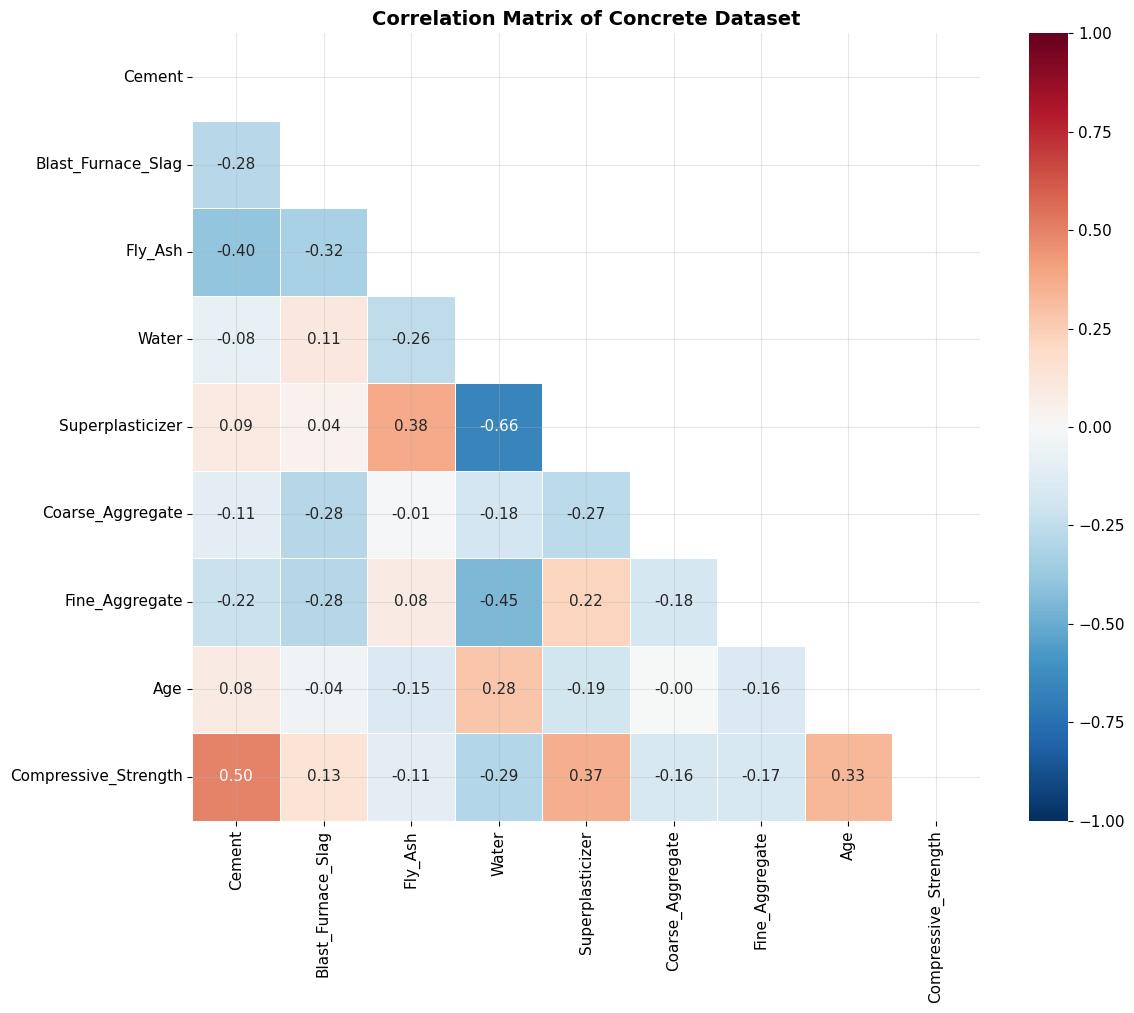


Correlation with Compressive_Strength (sorted by absolute value):
Cement                   : +0.498 (Moderate Positive)
Superplasticizer         : +0.366 (Moderate Positive)
Age                      : +0.329 (Moderate Positive)
Water                    : -0.290 (Weak Negative)
Fine_Aggregate           : -0.167 (Weak Negative)
Coarse_Aggregate         : -0.165 (Weak Negative)
Blast_Furnace_Slag       : +0.135 (Weak Positive)
Fly_Ash                  : -0.106 (Weak Negative)


In [9]:
# 상관관계 분석 (Correlation Analysis)
#corr() 메서드는 모든 수치형 변수 간의 피어슨 상관계수를 계산

fig, ax = plt.subplots(figsize=(12, 10))

# 상관계수 행렬 계산
corr_matrix = df_concrete.corr()

# 상삼각 마스크 생성 (대각선 위쪽만 숨김 - 중복 제거)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 히트맵 그리기
# cmap='RdBu_r': 빨강(양의 상관) - 흰색(무상관) - 파랑(음의 상관)
# center=0: 0을 중심으로 색상 배치
# annot=True: 각 셀에 상관계수 값 표시
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1)  # 상관계수 범위 고정

ax.set_title('Correlation Matrix of Concrete Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 타겟 변수와의 상관계수 정렬 출력
print("\nCorrelation with Compressive_Strength (sorted by absolute value):")
print("=" * 60)
corr_with_target = corr_matrix['Compressive_Strength'].drop('Compressive_Strength')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

for var in corr_sorted.index:
    val = corr_with_target[var]
    strength = "Strong" if abs(val) > 0.5 else "Moderate" if abs(val) > 0.3 else "Weak"
    direction = "Positive" if val > 0 else "Negative"
    print(f"{var:25}: {val:+.3f} ({strength} {direction})")

### 산점도를 통한 비선형 관계 확인

상관계수만으로는 **비선형 관계**를 파악하기 어려움. 산점도(Scatter Plot)를 통해 실제 데이터 분포와 관계의 형태를 시각적으로 확인함.

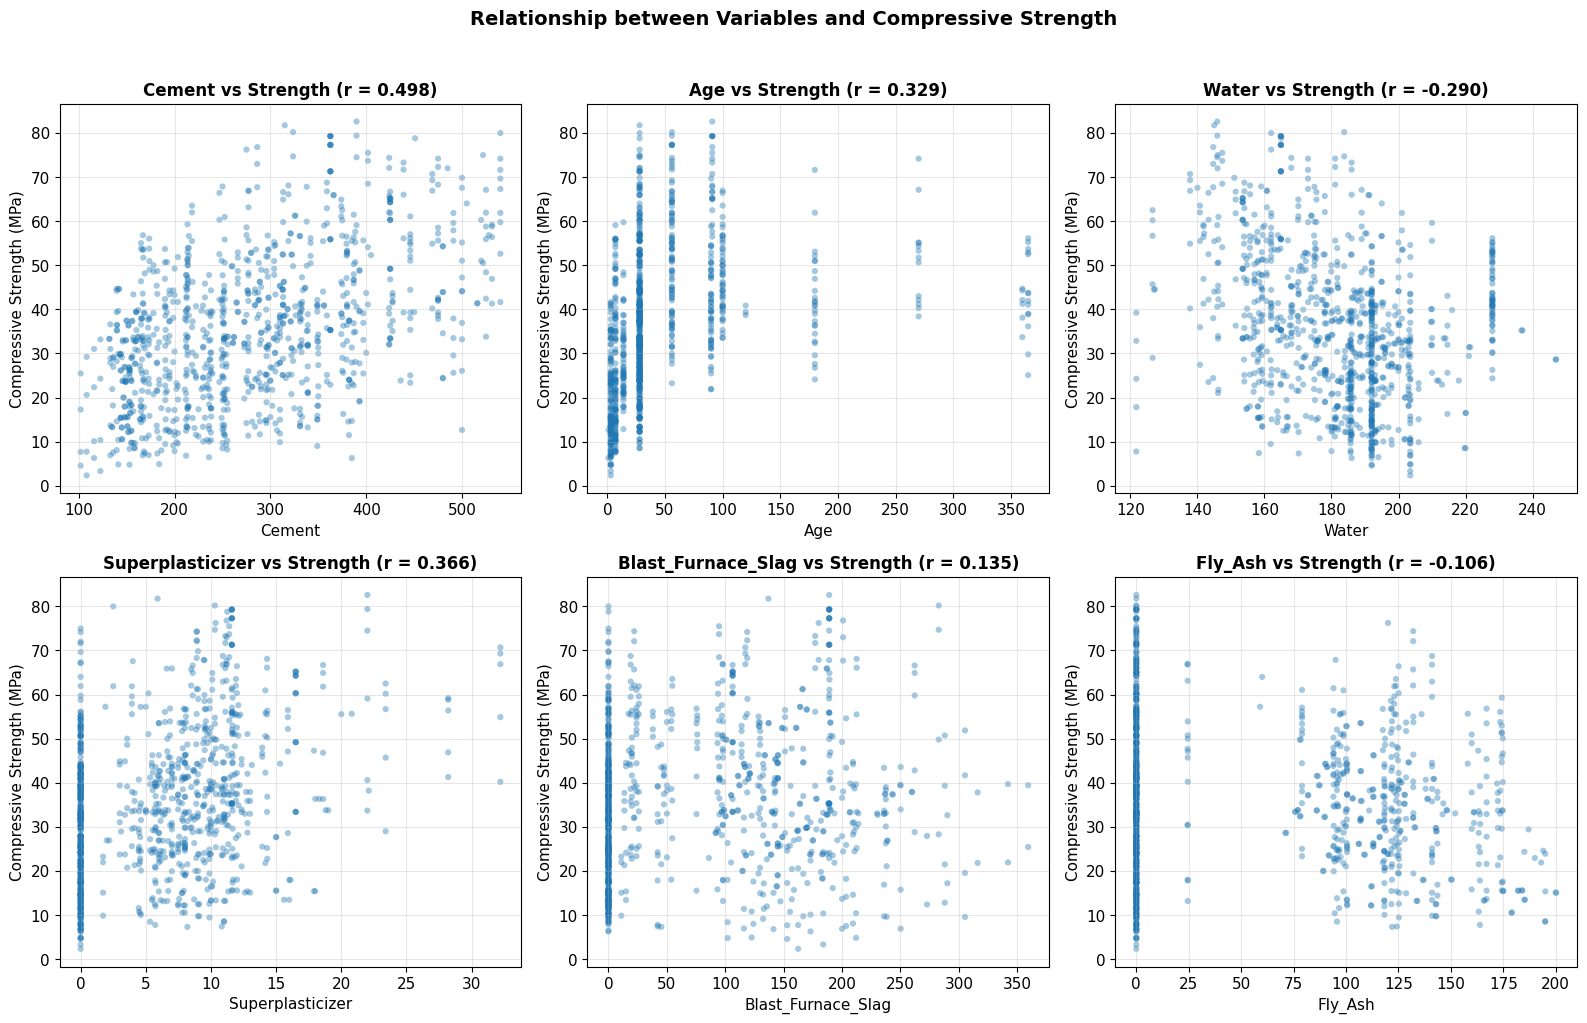


[Key Observations]
1. Age vs Strength: Clear NONLINEAR pattern - rapid initial increase, then saturation
2. Cement vs Strength: Positive relationship, but with some scatter
3. Water vs Strength: Negative relationship (higher W/C ratio = lower strength)

-> The Age-Strength relationship suggests polynomial regression is appropriate


In [10]:
# 주요 변수와 압축 강도의 관계 시각화
# 산점도를 통해 선형/비선형 관계를 시각적으로 확인
# alpha(투명도)를 낮게 설정하여 데이터 밀집 영역 파악

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 분석할 주요 변수 선택 (상관계수가 높거나 도메인적으로 중요한 변수)
key_vars = ['Cement', 'Age', 'Water', 'Superplasticizer', 'Blast_Furnace_Slag', 'Fly_Ash']

for ax, var in zip(axes.flatten(), key_vars):
    # 산점도 그리기
    ax.scatter(df_concrete[var], df_concrete['Compressive_Strength'], 
               alpha=0.4,        # 투명도: 데이터 밀집 영역 확인
               s=20,             # 점 크기
               edgecolor='none') # 테두리 없음
    
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('Compressive Strength (MPa)', fontsize=11)
    
    # 상관계수 계산 및 표시
    corr = df_concrete[var].corr(df_concrete['Compressive_Strength'])
    ax.set_title(f'{var} vs Strength (r = {corr:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('Relationship between Variables and Compressive Strength', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n[Key Observations]")
print("1. Age vs Strength: Clear NONLINEAR pattern - rapid initial increase, then saturation")
print("2. Cement vs Strength: Positive relationship, but with some scatter")
print("3. Water vs Strength: Negative relationship (higher W/C ratio = lower strength)")
print("\n-> The Age-Strength relationship suggests polynomial regression is appropriate")

## 1.8 다항회귀 실습: Age로 Compressive Strength 예측

### 데이터 분할의 이론적 배경

모델의 **일반화 성능**을 평가하기 위해 데이터를 학습용(Train)과 테스트용(Test)으로 분할함:

- **Train set**: 모델 학습에 사용
- **Test set**: 학습에 사용되지 않은 새로운 데이터로 모델 평가

일반적인 분할 비율: 80:20 또는 70:30

**`random_state` 파라미터**: 동일한 값을 사용하면 매번 같은 방식으로 분할되어 결과 재현 가능

In [11]:
# 데이터 준비: Age -> Compressive_Strength 예측
# 단일 변수(Age)로 다항회귀의 효과를 명확히 확인

# 독립변수 (X): Age - 2D 배열로 변환 필요 (sklearn 요구사항)
X = df_concrete[['Age']].values

# 종속변수 (y): Compressive_Strength
y = df_concrete['Compressive_Strength'].values

# Train/Test 분할
# test_size=0.2: 20%를 테스트용으로 분리
# random_state=42: 재현성을 위한 시드 고정

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 테스트 비율
    random_state=42     # 재현성
)

print("=" * 60)
print("Data Split Results")
print("=" * 60)
print(f"\nTotal samples: {len(X):,}")
print(f"Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples: {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nAge range: {X.min():.0f} ~ {X.max():.0f} days")
print(f"Strength range: {y.min():.1f} ~ {y.max():.1f} MPa")

Data Split Results

Total samples: 1,030
Training samples: 824 (80%)
Test samples: 206 (20%)

Age range: 1 ~ 365 days
Strength range: 2.3 ~ 82.6 MPa


### 차수별 다항회귀 성능 비교

다항회귀에서 **차수(degree)** 선택은 매우 중요함. 차수가 너무 낮으면 과소적합, 너무 높으면 과대적합이 발생함.

**평가 지표**:

1. **R² (결정계수)**: 모델이 설명하는 분산의 비율
   $$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$
   - 범위: 0 ~ 1 (1에 가까울수록 좋음)

2. **RMSE (평균 제곱근 오차)**: 예측 오차의 크기
   $$RMSE = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$$
   - 단위가 타겟 변수와 동일 (해석 용이)

In [12]:
# 차수별 다항회귀 모델 학습 및 성능 비교
# 1차(선형)부터 6차까지 다항회귀 모델을 학습하고 성능 비교

degrees = [1, 2, 3, 4, 5, 6]  # 테스트할 차수 목록
results = []                  # 결과 저장용 리스트
models = {}                   # 학습된 모델 저장용 딕셔너리

print("=" * 90)
print("Polynomial Regression Performance by Degree")
print("=" * 90)
print(f"{'Degree':>6} | {'Train R²':>10} | {'Test R²':>10} | {'Train RMSE':>12} | {'Test RMSE':>12} | {'Gap':>8} | {'Status'}")
print("-" * 90)

for deg in degrees:
    # =========================================================================
    # Pipeline 생성: PolynomialFeatures -> LinearRegression
    # =========================================================================
    # Pipeline은 전처리와 모델을 순차적으로 연결
    # include_bias=False: 절편은 LinearRegression에서 처리
    
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('linear', LinearRegression())
    ])
    
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # =========================================================================
    # 평가 지표 계산
    # =========================================================================
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Gap: 과대적합 지표 (Train R² - Test R²)
    gap = train_r2 - test_r2
    
    # 결과 저장
    results.append({
        'degree': deg, 
        'train_r2': train_r2, 
        'test_r2': test_r2,
        'train_rmse': train_rmse, 
        'test_rmse': test_rmse, 
        'gap': gap
    })
    models[deg] = model
    
    # 상태 판정
    if gap > 0.1:
        status = "Overfitting"
    elif gap > 0.05:
        status = "Warning"
    else:
        status = "Good"
    
    print(f"{deg:>6} | {train_r2:>10.4f} | {test_r2:>10.4f} | {train_rmse:>12.2f} | {test_rmse:>12.2f} | {gap:>8.4f} | {status}")

# 최적 차수 결정 (Test R²가 가장 높은 차수)
best_result = max(results, key=lambda x: x['test_r2'])
print("-" * 90)
print(f"\nOptimal degree: {best_result['degree']} (Test R² = {best_result['test_r2']:.4f}, RMSE = {best_result['test_rmse']:.2f} MPa)")

Polynomial Regression Performance by Degree
Degree |   Train R² |    Test R² |   Train RMSE |    Test RMSE |      Gap | Status
------------------------------------------------------------------------------------------
     1 |     0.1103 |     0.0959 |        15.90 |        15.26 |   0.0144 | Good
     2 |     0.2589 |     0.2460 |        14.51 |        13.94 |   0.0130 | Good
     3 |     0.3241 |     0.2913 |        13.86 |        13.51 |   0.0328 | Good
     4 |     0.3526 |     0.3270 |        13.56 |        13.17 |   0.0256 | Good
     5 |     0.3533 |     0.3255 |        13.55 |        13.18 |   0.0278 | Good
     6 |     0.3470 |     0.3157 |        13.62 |        13.28 |   0.0314 | Good
------------------------------------------------------------------------------------------

Optimal degree: 4 (Test R² = 0.3270, RMSE = 13.17 MPa)


### 결과 해석

위 표에서 확인할 수 있는 패턴:

1. **차수 증가에 따른 Train R² 증가**: 차수가 높아질수록 학습 데이터에 더 잘 맞음
2. **Test R²의 정체 또는 감소**: 특정 차수 이후 새로운 데이터에 대한 성능이 나빠짐
3. **Gap 증가**: 과대적합의 명확한 징후

**최적 차수**는 Test R²가 가장 높으면서 Gap이 작은 차수임.

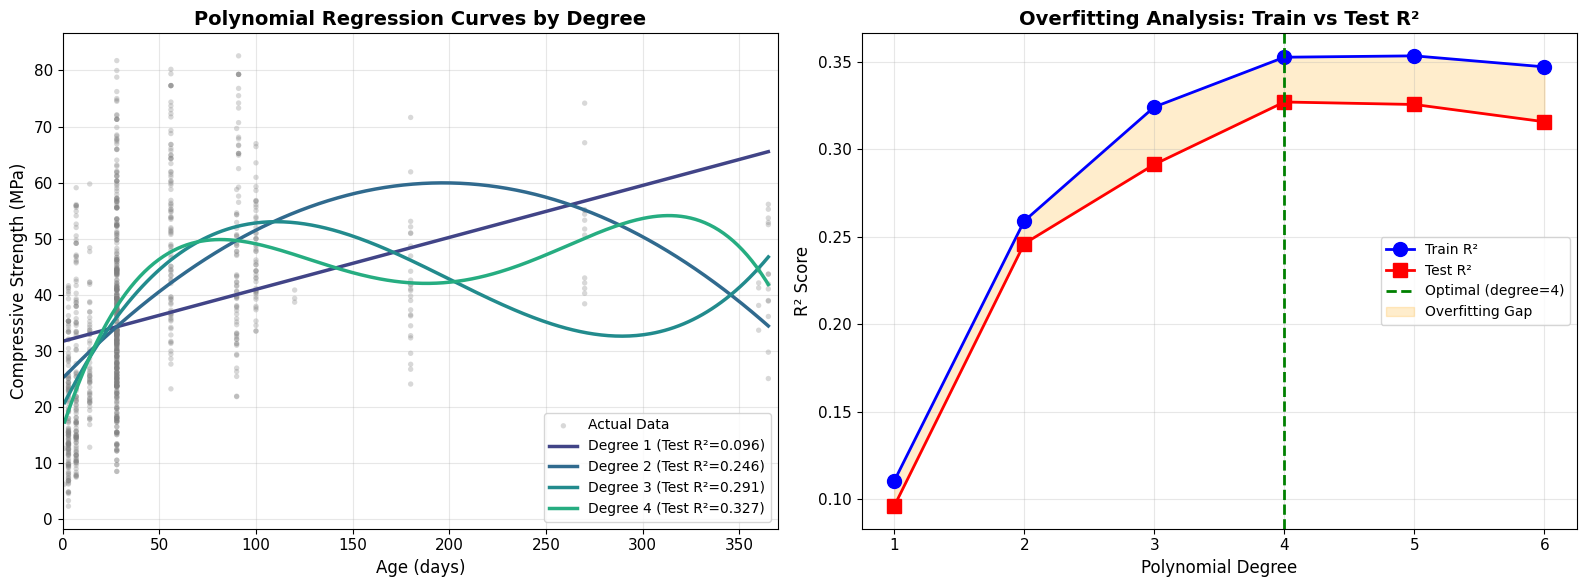


[Interpretation]
- Left plot: Higher degree curves fit the data more closely, but may oscillate
- Right plot: The gap between Train and Test R² increases with degree (overfitting)
- Optimal choice: Degree 4 balances fit quality and generalization


In [13]:
# 회귀 곡선 및 과대적합 분석 시각화

# 예측을 위한 X 범위 생성 (부드러운 곡선을 위해 300개 점)
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 좌측: 회귀 곡선 비교
ax1 = axes[0]

# 원본 데이터 산점도
ax1.scatter(X, y, alpha=0.3, s=15, label='Actual Data', color='gray', edgecolor='none')

# 색상 팔레트 생성
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(degrees)))

# 각 차수별 회귀 곡선 그리기 (처음 4개만)
for deg, color in zip(degrees[:4], colors[:4]):
    y_plot = models[deg].predict(X_plot)
    test_r2 = results[deg-1]['test_r2']
    ax1.plot(X_plot, y_plot, color=color, linewidth=2.5,
             label=f'Degree {deg} (Test R²={test_r2:.3f})')

ax1.set_xlabel('Age (days)', fontsize=12)
ax1.set_ylabel('Compressive Strength (MPa)', fontsize=12)
ax1.set_title('Polynomial Regression Curves by Degree', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_xlim([0, 370])

# 우측: 과대적합 분석 (Train vs Test R²)
ax2 = axes[1]
df_results = pd.DataFrame(results)

# Train R²와 Test R² 곡선
ax2.plot(df_results['degree'], df_results['train_r2'], 'b-o', 
         linewidth=2, markersize=10, label='Train R²')
ax2.plot(df_results['degree'], df_results['test_r2'], 'r-s', 
         linewidth=2, markersize=10, label='Test R²')

# 최적 차수 표시
best_deg = best_result['degree']
ax2.axvline(x=best_deg, color='green', linestyle='--', 
            linewidth=2, label=f'Optimal (degree={best_deg})')

# 과대적합 영역 (Gap) 표시
ax2.fill_between(df_results['degree'], df_results['train_r2'], df_results['test_r2'],
                 alpha=0.2, color='orange', label='Overfitting Gap')

ax2.set_xlabel('Polynomial Degree', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('Overfitting Analysis: Train vs Test R²', fontsize=14, fontweight='bold')
ax2.legend(loc='center right', fontsize=10)
ax2.set_xticks(degrees)

plt.tight_layout()
plt.show()

print("\n[Interpretation]")
print("- Left plot: Higher degree curves fit the data more closely, but may oscillate")
print("- Right plot: The gap between Train and Test R² increases with degree (overfitting)")
print(f"- Optimal choice: Degree {best_deg} balances fit quality and generalization")

## 1.9 최적 모델의 계수 해석

다항회귀 모델의 계수는 물리적 의미를 가짐. 계수를 분석하여 변수 간의 관계를 이해할 수 있음.

In [14]:
# 최적 모델의 계수 분석
optimal_degree = best_result['degree']
best_model = models[optimal_degree]

# Pipeline에서 각 단계 추출
poly_transformer = best_model.named_steps['poly']   # 특성 변환기
linear_regressor = best_model.named_steps['linear'] # 선형회귀 모델

# 변환된 특성 이름 얻기
feature_names = poly_transformer.get_feature_names_out(['Age'])

print("=" * 70)
print(f"Polynomial Regression Model Coefficients (degree={optimal_degree})")
print("=" * 70)

# 절편 출력
print(f"\nIntercept (β₀): {linear_regressor.intercept_:.4f}")
print("  -> Predicted strength when Age = 0 (theoretical, not practical)")

# 각 계수 출력
print(f"\nCoefficients:")
for i, (name, coef) in enumerate(zip(feature_names, linear_regressor.coef_), 1):
    print(f"  β{i} ({name:10}): {coef:+.8f}")

# 회귀식 출력
print(f"\n" + "=" * 70)
print("Regression Equation:")
print("=" * 70)
equation = f"Strength = {linear_regressor.intercept_:.4f}"
for name, coef in zip(feature_names, linear_regressor.coef_):
    sign = "+" if coef >= 0 else ""
    # 과학적 표기법으로 변환
    equation += f" {sign}{coef:.6f}*{name}"
print(equation)

Polynomial Regression Model Coefficients (degree=4)

Intercept (β₀): 16.3083
  -> Predicted strength when Age = 0 (theoretical, not practical)

Coefficients:
  β1 (Age       ): +1.04440148
  β2 (Age^2     ): -0.01084262
  β3 (Age^3     ): +0.00004220
  β4 (Age^4     ): -0.00000005

Regression Equation:
Strength = 16.3083 +1.044401*Age -0.010843*Age^2 +0.000042*Age^3 -0.000000*Age^4


### 실제 예측 예시

학습된 모델을 사용하여 다양한 양생 기간에서의 콘크리트 강도를 예측함.

In [16]:
# 양생 기간별 강도 예측
# 실무에서 자주 사용되는 양생 기간에 대해 예측

print("\n" + "=" * 60)
print("Strength Prediction by Curing Age")
print("=" * 60)

# 주요 양생 기간 (일반적인 콘크리트 테스트 일정)
test_ages = [1, 3, 7, 14, 28, 56, 90, 180, 365]

print(f"\n{'Age (days)':>12} | {'Predicted Strength (MPa)':>25} | {'Note'}")
print("-" * 70)

for age in test_ages:
    pred = best_model.predict([[age]])[0]
    
    # 참고 사항 추가
    if age == 7:
        note = "Early strength test"
    elif age == 28:
        note = "Standard design strength (f'c)"
    elif age == 90:
        note = "Long-term strength"
    else:
        note = ""
    
    print(f"{age:>12} | {pred:>25.2f} | {note}")

print("\n[Note]")
print("- 28-day strength is the standard reference in concrete design")
print("- Concrete continues to gain strength over time (hydration process)")
print("- The rate of strength gain decreases with time (logarithmic pattern)")


Strength Prediction by Curing Age

  Age (days) |  Predicted Strength (MPa) | Note
----------------------------------------------------------------------
           1 |                     17.34 | 
           3 |                     19.35 | 
           7 |                     23.10 | Early strength test
          14 |                     28.92 | 
          28 |                     37.94 | Standard design strength (f'c)
          56 |                     47.67 | 
          90 |                     49.68 | Long-term strength
         180 |                     42.14 | 
         365 |                     41.86 | 

[Note]
- 28-day strength is the standard reference in concrete design
- Concrete continues to gain strength over time (hydration process)
- The rate of strength gain decreases with time (logarithmic pattern)


---

# 2: 분류 문제와 시그모이드 함수

---

## 2.1 회귀 vs 분류 문제

머신러닝의 지도학습(Supervised Learning)은 크게 **회귀**와 **분류** 문제로 나뉨.

| 구분 | 회귀 (Regression) | 분류 (Classification) |
|:-----|:------------------|:----------------------|
| **출력 형태** | 연속적인 숫자 | 이산적인 범주 (카테고리) |
| **예시** | 콘크리트 강도: 35.7 MPa | 철강 결함: 정상/결함 |
| **질문 유형** | "얼마나?" (How much?) | "무엇인가?" (What/Which?) |
| **손실 함수** | MSE, MAE | Cross-Entropy, Log Loss |
| **평가 지표** | R², RMSE, MAE | Accuracy, Precision, Recall, F1 |
| **대표 알고리즘** | Linear Regression, Polynomial Regression | Logistic Regression, SVM, Random Forest |

### 제조 현장에서의 분류 문제 예시

| 문제 | 클래스 | 비즈니스 영향 |
|:-----|:-------|:--------------|
| 품질 검사 | 양품 / 불량 | 불량 유출 시 고객 클레임, 리콜 비용 |
| 결함 유형 분류 | 스크래치 / 크랙 / 오염 | 결함 원인 파악 및 공정 개선 |
| 설비 상태 예측 | 정상 / 주의 / 위험 | 예방 정비로 다운타임 최소화 |
| 공정 이상 탐지 | 정상 / 이상 | 실시간 품질 관리 |

## 2.2 분류 문제에 선형회귀를 사용할 수 없는 이유

분류 문제의 타겟 변수는 **범주형**임 (예: 0=양품, 1=불량). 선형회귀를 직접 적용하면 다음 문제가 발생함:

1. **출력 범위 문제**: 선형회귀는 $-\infty$ ~ $+\infty$ 범위의 값을 출력
   - 예측값이 1.5나 -0.3이면 확률로 해석 불가능

2. **확률 해석 불가**: 0~1 범위를 보장하지 않음

3. **이상치 민감도**: 극단적인 X 값이 회귀선을 왜곡

이 문제를 해결하기 위해 **시그모이드 함수**를 도입함.

## 2.3 시그모이드 함수 (Sigmoid Function)

### 수학적 정의

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 핵심 특성

| 특성 | 설명 | 수학적 표현 |
|:-----|:-----|:-----------|
| **출력 범위** | 항상 $(0, 1)$ 사이 | $0 < \sigma(z) < 1$ |
| **중심점** | $z=0$일 때 0.5 | $\sigma(0) = 0.5$ |
| **단조 증가** | z가 커지면 출력도 증가 | $\sigma'(z) > 0$ |
| **점근선** | 극한값이 0과 1 | $\lim_{z \to \infty} \sigma(z) = 1$ |
| **대칭성** | 원점 대칭 | $\sigma(-z) = 1 - \sigma(z)$ |
| **미분** | 자기 자신으로 표현 가능 | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ |

### 주요 z 값에서의 시그모이드 값

| $z$ | $\sigma(z)$ | 확률 해석 |
|:---:|:-----------:|:----------|
| -5 | 0.0067 | 거의 확실히 Class 0 (0.67%) |
| -2 | 0.1192 | Class 0 가능성 높음 (11.9%) |
| -1 | 0.2689 | Class 0 쪽으로 기울어짐 |
| 0 | 0.5000 | 불확실 (50:50) |
| +1 | 0.7311 | Class 1 쪽으로 기울어짐 |
| +2 | 0.8808 | Class 1 가능성 높음 (88.1%) |
| +5 | 0.9933 | 거의 확실히 Class 1 (99.3%) |

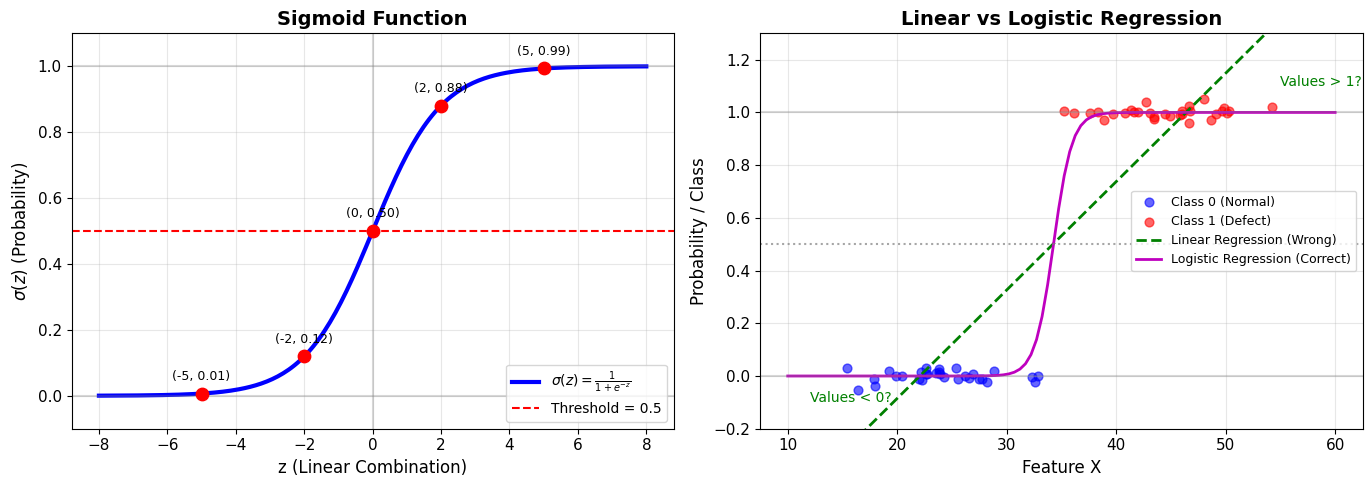

In [18]:
# =============================================================================
# 시그모이드 함수 정의 및 시각화
# =============================================================================

def sigmoid(z):
    """
    시그모이드 함수: 모든 실수를 (0, 1) 범위로 변환
    
    Parameters:
    -----------
    z : array-like
        입력값 (선형 결합 결과)
    
    Returns:
    --------
    array-like
        (0, 1) 범위의 확률값
    """
    return 1 / (1 + np.exp(-z))

# z 값 범위 생성
z = np.linspace(-8, 8, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================================================================
# 좌측: 시그모이드 함수 그래프
# =========================================================================
ax1 = axes[0]
ax1.plot(z, sigmoid(z), 'b-', linewidth=3, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')

# 기준선 표시
ax1.axhline(y=0.5, color='r', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

# 주요 점 표시
key_points = [-5, -2, 0, 2, 5]
for zp in key_points:
    sp = sigmoid(zp)
    ax1.scatter([zp], [sp], color='red', s=80, zorder=5)
    ax1.annotate(f'({zp}, {sp:.2f})', (zp, sp), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=9)

ax1.set_xlabel('z (Linear Combination)', fontsize=12)
ax1.set_ylabel(r'$\sigma(z)$ (Probability)', fontsize=12)
ax1.set_title('Sigmoid Function', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_ylim([-0.1, 1.1])

# =========================================================================
# 우측: 선형회귀 vs 로지스틱 회귀 비교
# =========================================================================
ax2 = axes[1]

# 가상의 이진 분류 데이터 생성
np.random.seed(42)
X_demo = np.concatenate([np.random.normal(25, 5, 30), np.random.normal(45, 5, 30)])
y_demo = np.concatenate([np.zeros(30), np.ones(30)])

# 선형회귀 (잘못된 접근)
lr_wrong = LinearRegression()
lr_wrong.fit(X_demo.reshape(-1, 1), y_demo)
X_line = np.linspace(10, 60, 100).reshape(-1, 1)
y_linear = lr_wrong.predict(X_line)

# 로지스틱 회귀 (올바른 접근)
lr_correct = LogisticRegression()
lr_correct.fit(X_demo.reshape(-1, 1), y_demo)
y_logistic = lr_correct.predict_proba(X_line)[:, 1]

# 데이터 포인트
ax2.scatter(X_demo[y_demo==0], y_demo[y_demo==0] + np.random.normal(0, 0.02, 30), 
           alpha=0.6, label='Class 0 (Normal)', color='blue', s=40)
ax2.scatter(X_demo[y_demo==1], y_demo[y_demo==1] + np.random.normal(0, 0.02, 30), 
           alpha=0.6, label='Class 1 (Defect)', color='red', s=40)

# 모델 예측선
ax2.plot(X_line, y_linear, 'g--', linewidth=2, label='Linear Regression (Wrong)')
ax2.plot(X_line, y_logistic, 'm-', linewidth=2, label='Logistic Regression (Correct)')

# 기준선
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.axhline(y=1, color='gray', linestyle='-', alpha=0.3)

ax2.set_xlabel('Feature X', fontsize=12)
ax2.set_ylabel('Probability / Class', fontsize=12)
ax2.set_title('Linear vs Logistic Regression', fontsize=14, fontweight='bold')
ax2.legend(loc='center right', fontsize=9)
ax2.set_ylim([-0.2, 1.3])

# 문제 영역 표시
ax2.annotate('Values > 1?', xy=(55, 1.1), fontsize=10, color='green')
ax2.annotate('Values < 0?', xy=(12, -0.1), fontsize=10, color='green')

plt.tight_layout()
plt.show()

## 2.4 로지스틱 회귀의 수학적 모델

### 모델 구조 (3단계)

**Step 1. 선형 결합 (Linear Combination)**

$$z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p = \mathbf{\beta}^T \mathbf{X}$$

**Step 2. 시그모이드 변환 (Probability)**

$$P(Y=1|\mathbf{X}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

**Step 3. 분류 결정 (Classification)**

$$\hat{Y} = \begin{cases} 1 & \text{if } P(Y=1|\mathbf{X}) \geq \text{threshold} \\ 0 & \text{if } P(Y=1|\mathbf{X}) < \text{threshold} \end{cases}$$

기본 threshold = 0.5

## 정리하자면

 **1. 시그모이드 함수의 정의역은 -ul ~ ul, 치역은 0~1사이**
 
 **2. 로지(Logi)스틱이므로 이러한 시그모이드를 통해 수행함**
 
 **3. 로지스틱 회귀는 회귀라는이름이 붙지만, 엄연히 말하자면 선형, 혹은다항회귀 이후 값을 로지스틱 함수인 시그모이드에 대응시켜 분류를 하는 *분류* 알고리즘임!**

# Part 3: 철강 결함 분류 모델 실습

## 3.1 Steel Plates Faults 데이터셋 소개

### 데이터셋 개요

- **출처**: UCI Machine Learning Repository
- **도메인**: 철강 제조 (스테인리스 스틸 판)
- **목적**: 표면 결함 유형 분류
- **샘플 수**: 1,941건
- **특성 수**: 27개 (결함 영역의 기하학적/광학적 측정값)
- **결함 유형**: 7종

### 결함 유형 설명

| 결함 유형 | 설명 | 원인 |
|:----------|:-----|:-----|
| Pastry | 층상 박리 | 압연 시 내부 결함 |
| Z_Scratch | Z자형 스크래치 | 이송 중 마찰 |
| K_Scratch | K자형 스크래치 | 롤 표면 손상 |
| Stains | 얼룩 | 윤활유/냉각수 오염 |
| Dirtiness | 이물질 부착 | 환경 오염 |
| Bumps | 돌기/융기 | 압연 불균일 |
| Other_Faults | 기타 결함 | 복합 원인 |

In [19]:
# =============================================================================
# Steel Plates Faults Dataset 로드
# =============================================================================
url_steel = "https://archive.ics.uci.edu/ml/machine-learning-databases/00198/Faults.NNA"

# 컬럼명 정의 (원본 데이터에는 헤더가 없음)
column_names = [
    # 기하학적 특성 (결함 영역의 위치와 크기)
    'X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum',
    'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 
    
    # 광학적 특성 (밝기/명도)
    'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 
    
    # 제조 조건
    'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 
    'Steel_Plate_Thickness', 
    
    # 형상 지수 (계산된 특성)
    'Edges_Index', 'Empty_Index', 'Square_Index', 
    'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index',
    'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index',
    'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas',
    
    # 타겟 변수: 7개 결함 유형 (One-hot encoded)
    'Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 
    'Dirtiness', 'Bumps', 'Other_Faults'
]

# 데이터 로드 (탭 구분)
df_steel = pd.read_csv(url_steel, sep='\t', header=None)
df_steel.columns = column_names

print("=" * 70)
print("Steel Plates Faults Dataset Loaded")
print("=" * 70)
print(f"\nData Shape: {df_steel.shape[0]:,} rows x {df_steel.shape[1]} columns")
print(f"Feature columns: 27")
print(f"Target columns: 7 (One-hot encoded fault types)")

Steel Plates Faults Dataset Loaded

Data Shape: 1,941 rows x 34 columns
Feature columns: 27
Target columns: 7 (One-hot encoded fault types)



Fault Type Distribution:
Other_Faults   :  673 ( 34.7%) **********************************
Bumps          :  402 ( 20.7%) ********************
K_Scratch      :  391 ( 20.1%) ********************
Z_Scratch      :  190 (  9.8%) *********
Pastry         :  158 (  8.1%) ********
Stains         :   72 (  3.7%) ***
Dirtiness      :   55 (  2.8%) **


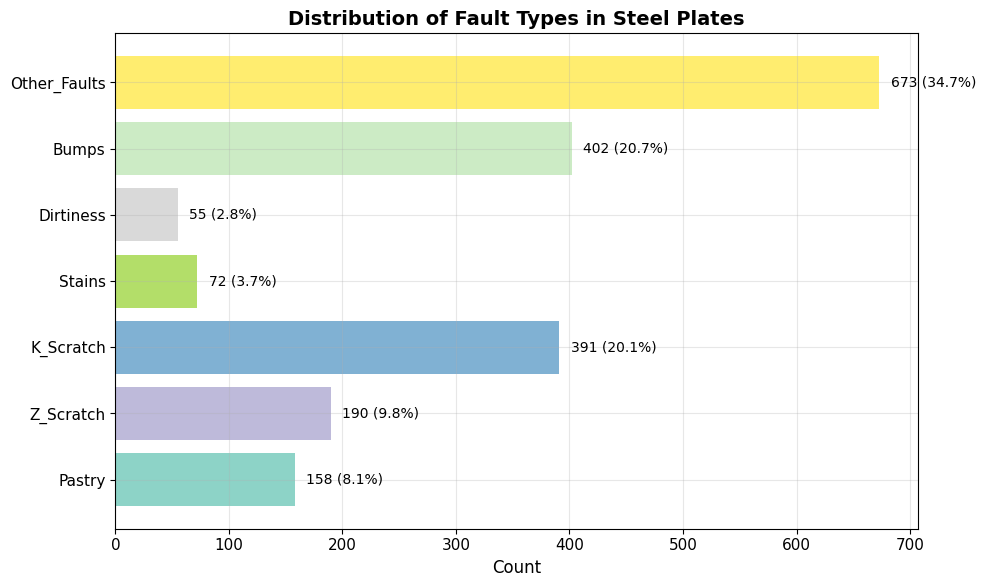

In [20]:
# =============================================================================
# 결함 유형별 분포 확인
# =============================================================================
fault_cols = ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

print("\nFault Type Distribution:")
print("=" * 60)

fault_counts = {col: df_steel[col].sum() for col in fault_cols}
for col, count in sorted(fault_counts.items(), key=lambda x: x[1], reverse=True):
    pct = count / len(df_steel) * 100
    bar = '*' * int(pct)
    print(f"{col:15}: {count:4} ({pct:5.1f}%) {bar}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(fault_cols)))
bars = ax.barh(fault_cols, [fault_counts[c] for c in fault_cols], color=colors)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Distribution of Fault Types in Steel Plates', fontsize=14, fontweight='bold')

for bar, col in zip(bars, fault_cols):
    width = bar.get_width()
    pct = width / len(df_steel) * 100
    ax.text(width + 10, bar.get_y() + bar.get_height()/2, 
            f'{int(width)} ({pct:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 3.2 이진 분류 문제로 변환

7개 결함 유형 중 **Bumps**(돌기/융기)를 타겟으로 선택하여 이진 분류 문제로 단순화함.
> 만약, 여러 클래스에 대한 로지스틱 회귀 분류를 하고 싶다면 소프트맥스(softmax)를 찾아볼 것!
**선택 이유**:
- 충분한 샘플 수 (402건, 20.7%)
- 명확한 물리적 원인 (압연 불균일)
- 품질에 직접적 영향

In [21]:
# =============================================================================
# 특성과 타겟 분리
# =============================================================================
feature_cols = column_names[:27]  # 처음 27개가 특성
X_steel = df_steel[feature_cols].values

# 이진 분류 타겟: Bumps 결함 여부
y_steel = df_steel['Bumps'].values

print("=" * 60)
print("Binary Classification: Bumps Defect Detection")
print("=" * 60)
print(f"\nClass distribution:")
print(f"  Class 0 (Non-Bumps): {(y_steel==0).sum():,} ({(y_steel==0).mean()*100:.1f}%)")
print(f"  Class 1 (Bumps):     {(y_steel==1).sum():,} ({(y_steel==1).mean()*100:.1f}%)")
print(f"\nImbalance ratio: 1 : {(y_steel==0).sum() / (y_steel==1).sum():.1f}")
print("\n[Note] This is an imbalanced dataset - will use class_weight='balanced'")

Binary Classification: Bumps Defect Detection

Class distribution:
  Class 0 (Non-Bumps): 1,539 (79.3%)
  Class 1 (Bumps):     402 (20.7%)

Imbalance ratio: 1 : 3.8

[Note] This is an imbalanced dataset - will use class_weight='balanced'


## 3.3 데이터 분할 및 스케일링

### 스케일링의 중요성

로지스틱 회귀는 **특성 스케일에 민감**함. 스케일링을 하지 않으면:

1. **수렴 속도 저하**: 경사하강법이 느리게 수렴
2. **계수 해석 어려움**: 스케일이 다른 특성 간 계수 비교 불가
3. **정규화 불균등**: L1/L2 정규화가 특정 특성에 편향

### StandardScaler

각 특성을 평균 0, 표준편차 1로 변환:

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

**주의**: `fit_transform`은 학습 데이터에만 적용, 테스트 데이터에는 `transform`만 적용 (데이터 누수 방지)

In [22]:
# =============================================================================
# 데이터 분할 (Train/Test Split)
# =============================================================================
# stratify=y_steel: 클래스 비율을 유지하면서 분할 (불균형 데이터에 중요)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_steel, y_steel, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_steel  # 클래스 비율 유지
)

print("=" * 60)
print("Data Split with Stratification")
print("=" * 60)
print(f"\nTraining samples: {len(X_train_s):,}")
print(f"  - Class 0: {(y_train_s==0).sum()} ({(y_train_s==0).mean()*100:.1f}%)")
print(f"  - Class 1: {(y_train_s==1).sum()} ({(y_train_s==1).mean()*100:.1f}%)")
print(f"\nTest samples: {len(X_test_s):,}")
print(f"  - Class 0: {(y_test_s==0).sum()} ({(y_test_s==0).mean()*100:.1f}%)")
print(f"  - Class 1: {(y_test_s==1).sum()} ({(y_test_s==1).mean()*100:.1f}%)")

Data Split with Stratification

Training samples: 1,552
  - Class 0: 1231 (79.3%)
  - Class 1: 321 (20.7%)

Test samples: 389
  - Class 0: 308 (79.2%)
  - Class 1: 81 (20.8%)


In [23]:
# =============================================================================
# 특성 스케일링 (StandardScaler)
# =============================================================================
# fit_transform: 학습 데이터로 평균/표준편차 계산 후 변환
# transform: 학습 데이터의 통계량으로 테스트 데이터 변환 (데이터 누수 방지)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_s)  # 학습 데이터: fit + transform
X_test_scaled = scaler.transform(X_test_s)        # 테스트 데이터: transform만

print("\nScaling Applied (StandardScaler)")
print("-" * 50)
print(f"Before scaling - Feature 0: mean={X_train_s[:, 0].mean():.2f}, std={X_train_s[:, 0].std():.2f}")
print(f"After scaling  - Feature 0: mean={X_train_scaled[:, 0].mean():.2f}, std={X_train_scaled[:, 0].std():.2f}")


Scaling Applied (StandardScaler)
--------------------------------------------------
Before scaling - Feature 0: mean=568.24, std=517.27
After scaling  - Feature 0: mean=-0.00, std=1.00


## 3.4 스케일링 효과 비교 (전처리의 중요성)

전처리(스케일링)를 하지 않았을 때와 했을 때의 성능 차이를 비교함.

In [26]:
# =============================================================================
# 스케일링 전후 성능 비교
# =============================================================================
print("=" * 70)
print("Effect of Feature Scaling on Logistic Regression")
print("=" * 70)

# Case 1: 스케일링 없이 학습
model_no_scale = LogisticRegression(max_iter=1000, random_state=42)
model_no_scale.fit(X_train_s, y_train_s)
acc_no_scale = model_no_scale.score(X_test_s, y_test_s)

# Case 2: 스케일링 적용 후 학습
model_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_scaled.fit(X_train_scaled, y_train_s)
acc_scaled = model_scaled.score(X_test_scaled, y_test_s)

print(f"\n{'Method':25} | {'Test Accuracy':>15} | {'Coefficient Range'}")
print("-" * 70)
print(f"{'Without Scaling':25} | {acc_no_scale:>15.4f} | [{model_no_scale.coef_.min():.4f}, {model_no_scale.coef_.max():.4f}]")
print(f"{'With StandardScaler':25} | {acc_scaled:>15.4f} | [{model_scaled.coef_.min():.4f}, {model_scaled.coef_.max():.4f}]")
print(f"\nImprovement: {(acc_scaled - acc_no_scale)*100:+.2f}%p")

Effect of Feature Scaling on Logistic Regression

Method                    |   Test Accuracy | Coefficient Range
----------------------------------------------------------------------
Without Scaling           |          0.7738 | [-0.0232, 0.0101]
With StandardScaler       |          0.8303 | [-1.6781, 1.0667]

Improvement: +5.66%p


## 3.5 로지스틱 회귀 모델 학습

### 불균형 데이터 처리

데이터가 불균형할 때 `class_weight='balanced'` 옵션을 사용하면:

$$w_j = \frac{n}{k \times n_j}$$

여기서 $n$은 전체 샘플 수, $k$는 클래스 수, $n_j$는 클래스 $j$의 샘플 수.

이렇게 하면 소수 클래스의 오분류에 더 큰 페널티를 부여함.

In [27]:
# =============================================================================
# 최종 모델 학습 (불균형 데이터 처리 포함)
# =============================================================================
# class_weight='balanced': 클래스 불균형 자동 보정
# max_iter=2000: 수렴을 위한 충분한 반복 횟수

model_final = LogisticRegression(
    max_iter=2000, 
    random_state=42, 
    class_weight='balanced'  # 불균형 데이터 처리
)
model_final.fit(X_train_scaled, y_train_s)

# 예측
y_pred_s = model_final.predict(X_test_scaled)         # 클래스 예측
y_proba_s = model_final.predict_proba(X_test_scaled)  # 확률 예측

print("=" * 60)
print("Logistic Regression Model Training Complete")
print("=" * 60)
print(f"\nModel parameters:")
print(f"  - max_iter: 2000")
print(f"  - class_weight: balanced")
print(f"  - solver: lbfgs (default)")
print(f"\nPerformance:")
print(f"  - Train Accuracy: {model_final.score(X_train_scaled, y_train_s):.4f}")
print(f"  - Test Accuracy:  {model_final.score(X_test_scaled, y_test_s):.4f}")

Logistic Regression Model Training Complete

Model parameters:
  - max_iter: 2000
  - class_weight: balanced
  - solver: lbfgs (default)

Performance:
  - Train Accuracy: 0.7571
  - Test Accuracy:  0.7069


## 3.6 혼동 행렬 (Confusion Matrix) 분석

### 혼동 행렬의 구조

```
                    예측 (Predicted)
                  Normal(0)   Bumps(1)
실제      Normal(0)   TN         FP
(Actual)  Bumps(1)    FN         TP
```

| 약어 | 전체 이름 | 의미 | 제조 현장 해석 |
|:----:|:----------|:-----|:--------------|
| TN | True Negative | 정상을 정상으로 예측 | 정확한 양품 판정 |
| TP | True Positive | 결함을 결함으로 예측 | 정확한 불량 검출 |
| FP | False Positive | 정상을 결함으로 예측 | **과검출** (Type I Error) |
| FN | False Negative | 결함을 정상으로 예측 | **누락** (Type II Error) - **위험!** |

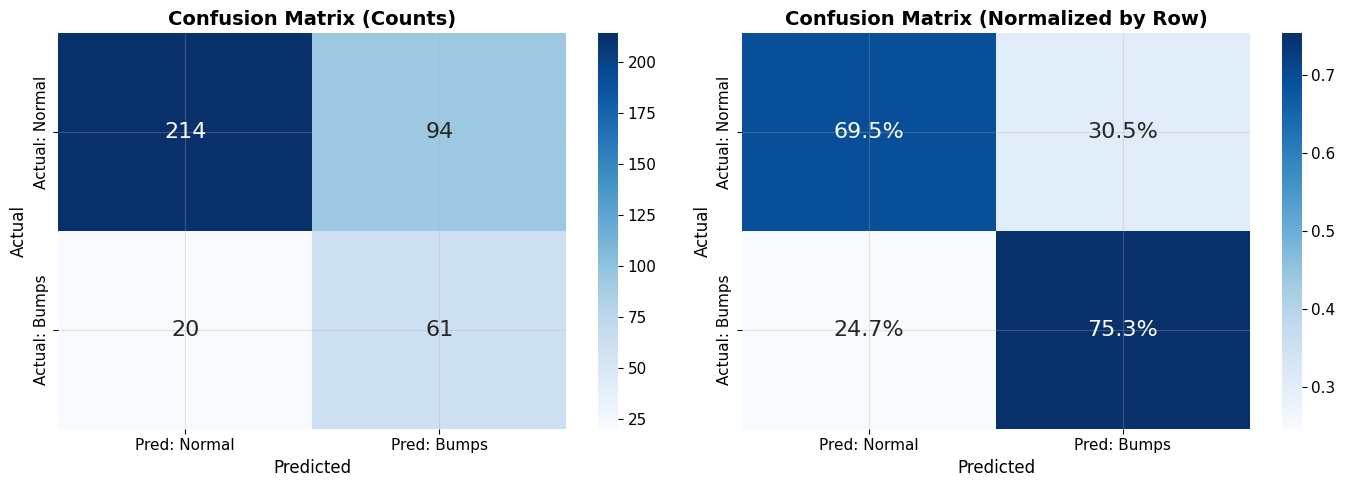


Confusion Matrix Interpretation

TN (True Negative):   214 - Normal correctly classified as Normal
FP (False Positive):   94 - Normal incorrectly classified as Bumps (Over-detection)
FN (False Negative):   20 - Bumps incorrectly classified as Normal (MISS - Dangerous!)
TP (True Positive):    61 - Bumps correctly classified as Bumps

[Manufacturing Impact]
  - FP (Over-detection): Unnecessary re-inspection cost
  - FN (Miss): Defective product may reach customer - CRITICAL!


In [28]:
# =============================================================================
# 혼동 행렬 계산 및 시각화
# =============================================================================
cm = confusion_matrix(y_test_s, y_pred_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌측: 개수 기반 혼동 행렬
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred: Normal', 'Pred: Bumps'],
            yticklabels=['Actual: Normal', 'Actual: Bumps'],
            annot_kws={'size': 16})
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_xlabel('Predicted', fontsize=12)

# 우측: 비율 기반 혼동 행렬
ax2 = axes[1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues', ax=ax2,
            xticklabels=['Pred: Normal', 'Pred: Bumps'],
            yticklabels=['Actual: Normal', 'Actual: Bumps'],
            annot_kws={'size': 16})
ax2.set_title('Confusion Matrix (Normalized by Row)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

# 상세 해석
print("\n" + "=" * 70)
print("Confusion Matrix Interpretation")
print("=" * 70)
print(f"\nTN (True Negative):  {cm[0,0]:>4} - Normal correctly classified as Normal")
print(f"FP (False Positive): {cm[0,1]:>4} - Normal incorrectly classified as Bumps (Over-detection)")
print(f"FN (False Negative): {cm[1,0]:>4} - Bumps incorrectly classified as Normal (MISS - Dangerous!)")
print(f"TP (True Positive):  {cm[1,1]:>4} - Bumps correctly classified as Bumps")

print(f"\n[Manufacturing Impact]")
print(f"  - FP (Over-detection): Unnecessary re-inspection cost")
print(f"  - FN (Miss): Defective product may reach customer - CRITICAL!")

## 3.7 분류 평가 지표

### 주요 지표의 수학적 정의

| 지표 | 수식 | 의미 | 범위 |
|:-----|:-----|:-----|:-----|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | 전체 중 맞은 비율 | 0~1 |
| **Precision** | $\frac{TP}{TP + FP}$ | 결함 예측 중 실제 결함 비율 | 0~1 |
| **Recall** | $\frac{TP}{TP + FN}$ | 실제 결함 중 검출 성공 비율 | 0~1 |
| **F1 Score** | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ | 조화평균 | 0~1 |

In [29]:
# =============================================================================
# 분류 평가 지표 계산
# =============================================================================
accuracy = accuracy_score(y_test_s, y_pred_s)
precision = precision_score(y_test_s, y_pred_s)
recall = recall_score(y_test_s, y_pred_s)
f1 = f1_score(y_test_s, y_pred_s)

print("=" * 70)
print("Classification Metrics")
print("=" * 70)
print(f"\n{'Metric':15} | {'Value':>10} | {'Formula':30} | {'Interpretation'}")
print("-" * 90)
print(f"{'Accuracy':15} | {accuracy:>10.4f} | (TP+TN) / Total                | {accuracy:.1%} correct overall")
print(f"{'Precision':15} | {precision:>10.4f} | TP / (TP+FP)                   | {precision:.1%} of Bumps predictions are correct")
print(f"{'Recall':15} | {recall:>10.4f} | TP / (TP+FN)                   | {recall:.1%} of actual Bumps detected")
print(f"{'F1 Score':15} | {f1:>10.4f} | 2*Prec*Rec / (Prec+Rec)        | Harmonic mean of Precision & Recall")

print("\n" + "=" * 70)
print("Manufacturing Perspective")
print("=" * 70)
if recall < 0.9:
    print(f"\n[WARNING] Recall is {recall:.1%} (below 90%)")
    print(f"  -> {(1-recall)*100:.1f}% of actual Bumps defects are being MISSED")
    print(f"  -> Consider lowering the classification threshold to increase recall")
else:
    print(f"\n[GOOD] Recall is {recall:.1%} (above 90%)")
    print(f"  -> Most Bumps defects are being detected")

Classification Metrics

Metric          |      Value | Formula                        | Interpretation
------------------------------------------------------------------------------------------
Accuracy        |     0.7069 | (TP+TN) / Total                | 70.7% correct overall
Precision       |     0.3935 | TP / (TP+FP)                   | 39.4% of Bumps predictions are correct
Recall          |     0.7531 | TP / (TP+FN)                   | 75.3% of actual Bumps detected
F1 Score        |     0.5169 | 2*Prec*Rec / (Prec+Rec)        | Harmonic mean of Precision & Recall

Manufacturing Perspective

[WARNING] Recall is 75.3% (below 90%)
  -> 24.7% of actual Bumps defects are being MISSED
  -> Consider lowering the classification threshold to increase recall


In [30]:
# =============================================================================
# 상세 분류 보고서
# =============================================================================
print("\n" + "=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(y_test_s, y_pred_s, target_names=['Normal', 'Bumps']))


Classification Report
              precision    recall  f1-score   support

      Normal       0.91      0.69      0.79       308
       Bumps       0.39      0.75      0.52        81

    accuracy                           0.71       389
   macro avg       0.65      0.72      0.65       389
weighted avg       0.81      0.71      0.73       389



## 3.8 ROC 곡선과 AUC

### ROC 곡선 (Receiver Operating Characteristic)

- **X축**: False Positive Rate (FPR) = FP / (FP + TN)
- **Y축**: True Positive Rate (TPR) = Recall = TP / (TP + FN)

### AUC (Area Under Curve)

- ROC 곡선 아래 면적
- 0.5 (무작위) ~ 1.0 (완벽)
- **임계값에 독립적**인 모델 성능 지표

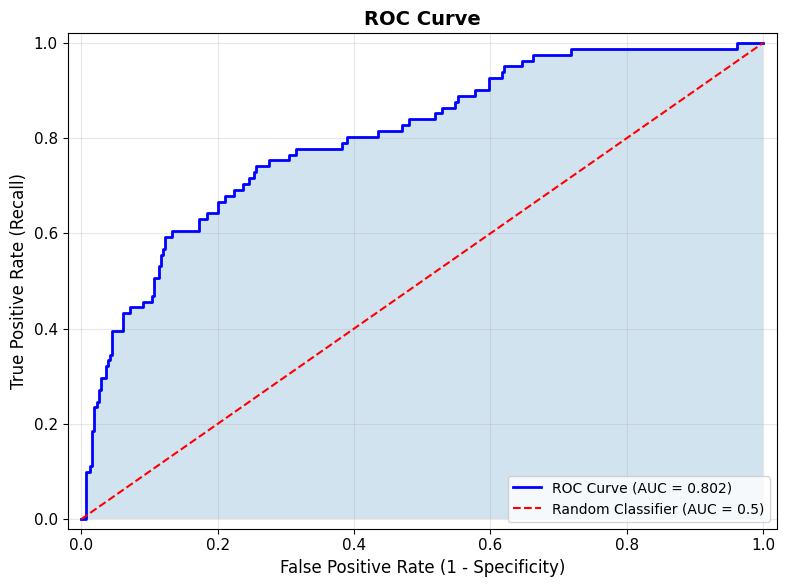


AUC (Area Under Curve): 0.8024

[AUC Interpretation]
  0.5:     Random classifier (useless)
  0.7-0.8: Acceptable
  0.8-0.9: Good
  0.9+:    Excellent


In [31]:
# =============================================================================
# ROC 곡선 및 AUC 계산
# =============================================================================
fpr, tpr, thresholds = roc_curve(y_test_s, y_proba_s[:, 1])
auc_score = roc_auc_score(y_test_s, y_proba_s[:, 1])

fig, ax = plt.subplots(figsize=(8, 6))

# ROC 곡선
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.2)

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

print(f"\nAUC (Area Under Curve): {auc_score:.4f}")
print("\n[AUC Interpretation]")
print("  0.5:     Random classifier (useless)")
print("  0.7-0.8: Acceptable")
print("  0.8-0.9: Good")
print("  0.9+:    Excellent")

## 3.9 임계값 조정 (Threshold Tuning)

### 임계값과 Precision-Recall Trade-off

기본 임계값은 0.5이지만, 비즈니스 요구에 따라 조정 가능:

- **임계값 낮춤**: Recall 증가, Precision 감소 (더 많이 검출, 과검출 증가)
- **임계값 높임**: Recall 감소, Precision 증가 (덜 검출, 과검출 감소)

**제조업에서는 불량 누락(FN)이 더 위험**하므로 낮은 임계값이 권장됨.

In [32]:
# =============================================================================
# 임계값별 성능 비교
# =============================================================================
thresholds_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print("=" * 90)
print("Performance by Classification Threshold")
print("=" * 90)
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1':>10} | {'FP':>6} | {'FN':>6}")
print("-" * 90)

for thresh in thresholds_test:
    # 임계값에 따른 예측
    y_pred_th = (y_proba_s[:, 1] >= thresh).astype(int)
    
    # 평가 지표 계산
    acc = accuracy_score(y_test_s, y_pred_th)
    prec = precision_score(y_test_s, y_pred_th, zero_division=0)
    rec = recall_score(y_test_s, y_pred_th, zero_division=0)
    f1_th = f1_score(y_test_s, y_pred_th, zero_division=0)
    
    # 혼동 행렬에서 FP, FN 추출
    cm_th = confusion_matrix(y_test_s, y_pred_th)
    fp = cm_th[0, 1]
    fn = cm_th[1, 0]
    
    marker = " <-- Default" if thresh == 0.5 else ""
    print(f"{thresh:>10.1f} | {acc:>10.4f} | {prec:>10.4f} | {rec:>10.4f} | {f1_th:>10.4f} | {fp:>6} | {fn:>6}{marker}")

print("\n[Interpretation]")
print("- Lower threshold: Higher Recall (fewer FN), Lower Precision (more FP)")
print("- Higher threshold: Lower Recall (more FN), Higher Precision (fewer FP)")
print("\n[Recommendation for Manufacturing]")
print("- Prioritize Recall to minimize missed defects (FN)")
print("- Accept some over-detection (FP) as cost of quality assurance")

Performance by Classification Threshold
 Threshold |   Accuracy |  Precision |     Recall |         F1 |     FP |     FN
------------------------------------------------------------------------------------------
       0.2 |     0.4987 |     0.2857 |     0.9383 |     0.4380 |    190 |      5
       0.3 |     0.5810 |     0.3119 |     0.8395 |     0.4548 |    150 |     13
       0.4 |     0.6350 |     0.3403 |     0.8025 |     0.4779 |    126 |     16
       0.5 |     0.7069 |     0.3935 |     0.7531 |     0.5169 |     94 |     20 <-- Default
       0.6 |     0.7661 |     0.4561 |     0.6420 |     0.5333 |     62 |     29
       0.7 |     0.8098 |     0.5443 |     0.5309 |     0.5375 |     36 |     38

[Interpretation]
- Lower threshold: Higher Recall (fewer FN), Lower Precision (more FP)
- Higher threshold: Lower Recall (more FN), Higher Precision (fewer FP)

[Recommendation for Manufacturing]
- Prioritize Recall to minimize missed defects (FN)
- Accept some over-detection (FP) as cost

## 3.10 특성 중요도 분석 (오즈비 해석)

로지스틱 회귀의 계수는 **오즈비** 로 해석할 수 있음:

$$\text{Odds Ratio} = e^{\beta_j}$$

- $e^{\beta} > 1$: 해당 특성 증가 시 결함 확률 증가
- $e^{\beta} < 1$: 해당 특성 증가 시 결함 확률 감소

In [33]:
# =============================================================================
# 특성 중요도 분석 (계수 및 오즈비)
# =============================================================================
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_final.coef_[0],
    'abs_coefficient': np.abs(model_final.coef_[0]),
    'odds_ratio': np.exp(model_final.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("=" * 90)
print("Top 10 Important Features (by absolute coefficient)")
print("=" * 90)
print(f"{'Rank':>4} | {'Feature':>25} | {'Coefficient':>12} | {'Odds Ratio':>12} | {'Effect on Bumps'}")
print("-" * 90)

for rank, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    effect = "Increases" if row['coefficient'] > 0 else "Decreases"
    print(f"{rank:>4} | {row['feature']:>25} | {row['coefficient']:>+12.4f} | {row['odds_ratio']:>12.4f} | {effect}")

Top 10 Important Features (by absolute coefficient)
Rank |                   Feature |  Coefficient |   Odds Ratio | Effect on Bumps
------------------------------------------------------------------------------------------
   1 |              Pixels_Areas |      -2.2459 |       0.1058 | Decreases
   2 |               Log_X_Index |      +1.2865 |       3.6202 | Increases
   3 |               X_Perimeter |      +1.0805 |       2.9460 | Increases
   4 |           Outside_X_Index |      -1.0477 |       0.3507 | Decreases
   5 |               Y_Perimeter |      -1.0348 |       0.3553 | Decreases
   6 |          Luminosity_Index |      -0.9192 |       0.3988 | Decreases
   7 |     Maximum_of_Luminosity |      +0.6622 |       1.9390 | Increases
   8 |              Square_Index |      +0.5601 |       1.7509 | Increases
   9 |             Edges_Y_Index |      +0.5203 |       1.6825 | Increases
  10 |         Sum_of_Luminosity |      -0.4910 |       0.6120 | Decreases


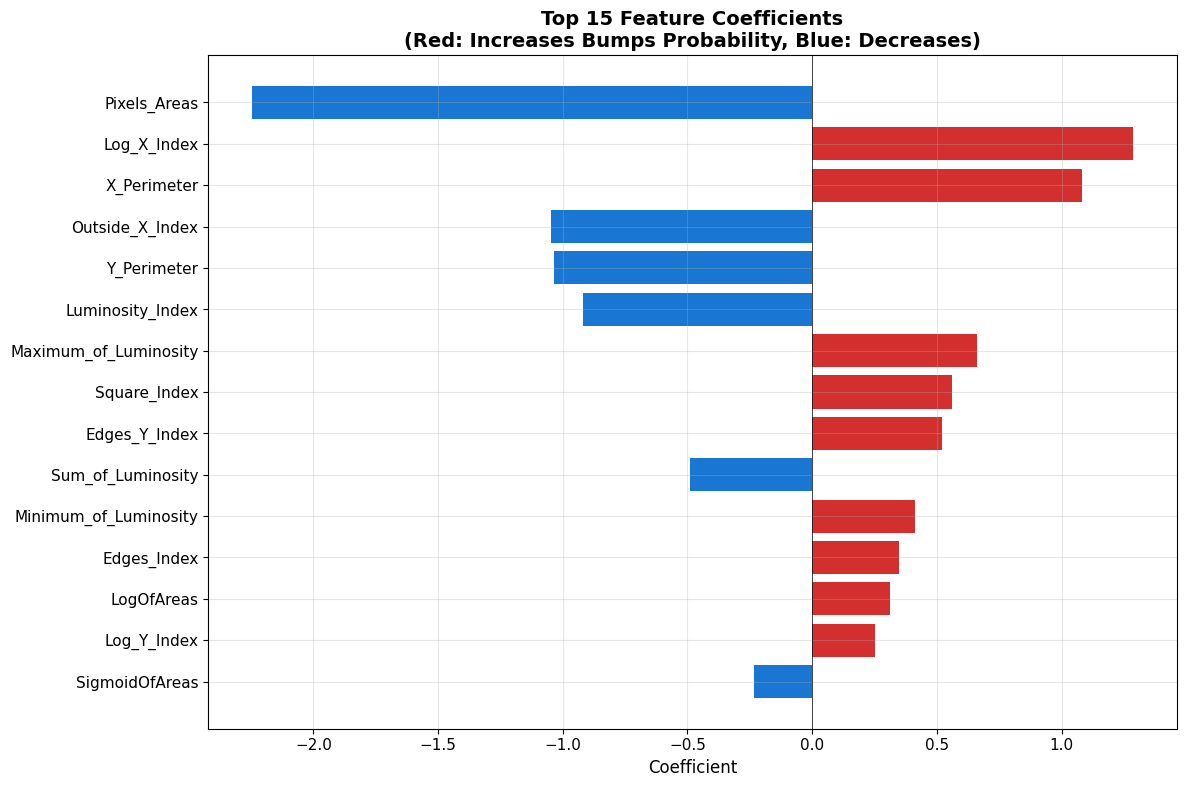

In [35]:
# =============================================================================
# 계수 시각화
# =============================================================================
top_n = 15
top_features = feature_importance.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 8))

# 색상: 양수(빨강) = 결함 증가, 음수(파랑) = 결함 감소
colors = ['#d32f2f' if c > 0 else '#1976d2' for c in top_features['coefficient']]
bars = ax.barh(range(top_n), top_features['coefficient'], color=colors)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_title('Top 15 Feature Coefficients\n(Red: Increases Bumps Probability, Blue: Decreases)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

---

## 핵심 정리

### 다항회귀 요약

| 개념 | 설명 |
|:-----|:-----|
| **정의** | $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + ... + \beta_n X^n$ |
| **특성 변환** | `PolynomialFeatures`로 $[1, X, X^2, ...]$ 생성 |
| **차수 선택** | 2~3차부터 시작, Test R² 기준으로 선택 |
| **과대적합 징후** | Train R² >> Test R² (Gap > 0.05) |

### 로지스틱 회귀 요약

| 개념 | 설명 |
|:-----|:-----|
| **시그모이드** | $\sigma(z) = \frac{1}{1 + e^{-z}}$, 출력 범위 $(0, 1)$ |
| **모델** | $P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + ...)}}$ |
| **오즈비** | $e^{\beta}$, 특성의 영향력 해석 |
| **스케일링** | 필수! StandardScaler 사용 |

### 분류 평가 지표

| 지표 | 수식 | 제조업 중요도 |
|:-----|:-----|:-------------|
| Accuracy | $(TP+TN)/\text{Total}$ | Medium |
| Precision | $TP/(TP+FP)$ | Medium (과검출 비용) |
| **Recall** | $TP/(TP+FN)$ | **High** (불량 검출) |
| F1 Score | Harmonic mean | High |


# 별첨: 소프트맥스(Softmax)를 이용한 다중 클래스 분류

## 개요

본 별첨에서는 앞서 학습한 이진 분류(Binary Classification)를 확장하여 **다중 클래스 분류(Multi-class Classification)**를 다룸. 시그모이드 함수가 2개 클래스를 구분하는 데 사용되었다면, **소프트맥스(Softmax) 함수**는 3개 이상의 클래스를 구분하는 데 사용됨.

### 학습 목표

1. 소프트맥스 함수의 수학적 정의와 특성을 이해함
2. 다중 클래스 로지스틱 회귀의 원리를 파악함
3. Steel Plates Faults 데이터셋의 7개 결함 유형을 분류하는 모델을 구축함

## A.1 이진 분류에서 다중 클래스 분류로의 확장

### 분류 문제의 유형

| 유형 | 클래스 수 | 예시 | 활성화 함수 |
|:-----|:---------:|:-----|:------------|
| **이진 분류** | 2 | 양품/불량, 정상/결함 | Sigmoid |
| **다중 클래스 분류** | 3+ | 결함 유형 7종, 제품 등급 A/B/C/D | **Softmax** |
| **다중 레이블 분류** | 2+ (복수 선택) | 이미지 태깅 (고양이 AND 실내) | Sigmoid (각 레이블별) |

### 제조 현장의 다중 클래스 분류 사례

| 분야 | 분류 문제 | 클래스 |
|:-----|:---------|:-------|
| 철강 제조 | 표면 결함 유형 분류 | Scratch, Stain, Crack, Bump, ... |
| 반도체 | 웨이퍼 불량 패턴 분류 | Center, Edge, Random, Scratch, ... |
| 자동차 | 도장 품질 등급 분류 | A급, B급, C급, 불량 |
| 식품 | 농산물 선별 | 특, 상, 중, 하 |

## A.2 소프트맥스 함수 (Softmax Function)

### 수학적 정의

$K$개의 클래스가 있을 때, 입력 벡터 $\mathbf{z} = [z_1, z_2, \ldots, z_K]$에 대해 소프트맥스 함수는 다음과 같이 정의됨:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad \text{for } i = 1, 2, \ldots, K$$

여기서:
- $z_i$: 클래스 $i$에 대한 선형 결합 결과 (logit)
- $e^{z_i}$: 지수 함수로 양수 변환
- $\sum_{j=1}^{K} e^{z_j}$: 정규화 상수 (모든 클래스의 합이 1이 되도록)

### 시그모이드와 소프트맥스의 관계

**시그모이드는 소프트맥스의 특수 케이스**임. $K=2$일 때:

$$\text{Softmax}(z_1) = \frac{e^{z_1}}{e^{z_1} + e^{z_2}} = \frac{1}{1 + e^{-(z_1 - z_2)}} = \sigma(z_1 - z_2)$$

### 소프트맥스의 핵심 특성

| 특성 | 설명 | 수학적 표현 |
|:-----|:-----|:-----------|
| **출력 범위** | 각 출력이 (0, 1) 사이 | $0 < \text{Softmax}(z_i) < 1$ |
| **합계 = 1** | 모든 클래스 확률의 합이 1 | $\sum_{i=1}^{K} \text{Softmax}(z_i) = 1$ |
| **확률 해석** | 각 클래스에 속할 확률 | $P(Y=i \mid \mathbf{X}) = \text{Softmax}(z_i)$ |
| **상대적 크기 보존** | $z_i > z_j$이면 $P_i > P_j$ | 순위 보존 |
| **미분 가능** | 경사하강법 적용 가능 | $\frac{\partial}{\partial z_i}$ 존재 |

### 수치 예시

3개 클래스에 대한 logit 값이 $\mathbf{z} = [2.0, 1.0, 0.1]$일 때:

**Step 1. 지수 변환**
$$e^{z_1} = e^{2.0} = 7.389, \quad e^{z_2} = e^{1.0} = 2.718, \quad e^{z_3} = e^{0.1} = 1.105$$

**Step 2. 합계 계산**
$$\sum e^{z_j} = 7.389 + 2.718 + 1.105 = 11.212$$

**Step 3. 확률 계산**
$$P_1 = \frac{7.389}{11.212} = 0.659, \quad P_2 = \frac{2.718}{11.212} = 0.242, \quad P_3 = \frac{1.105}{11.212} = 0.099$$

**결과**: $[0.659, 0.242, 0.099]$ → 합계 = 1.000, 클래스 1이 가장 높은 확률

## A.3 다중 클래스 로지스틱 회귀 (Multinomial Logistic Regression)

### 모델 구조

다중 클래스 로지스틱 회귀는 **Softmax Regression** 또는 **Multinomial Logit**이라고도 함.

**Step 1. 각 클래스별 선형 결합**

클래스 $k$에 대해:
$$z_k = \beta_{k,0} + \beta_{k,1} X_1 + \beta_{k,2} X_2 + \cdots + \beta_{k,p} X_p = \mathbf{\beta}_k^T \mathbf{X}$$

**Step 2. 소프트맥스 변환**
$$P(Y=k \mid \mathbf{X}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

**Step 3. 분류 결정**
$$\hat{Y} = \arg\max_{k} P(Y=k \mid \mathbf{X})$$

### 파라미터 수

| 항목 | 이진 분류 | 다중 클래스 (K개) |
|:-----|:---------:|:-----------------:|
| 특성 수 | $p$ | $p$ |
| 가중치 벡터 | 1개 | $K$개 (또는 $K-1$개) |
| 총 파라미터 | $p + 1$ | $K \times (p + 1)$ |

### 손실 함수: Cross-Entropy Loss

다중 클래스에서는 **Categorical Cross-Entropy**를 사용:

$$L = -\sum_{i=1}^{n} \sum_{k=1}^{K} y_{i,k} \log(\hat{p}_{i,k})$$

여기서:
- $y_{i,k}$: 샘플 $i$가 클래스 $k$에 속하면 1, 아니면 0 (One-hot encoding)
- $\hat{p}_{i,k}$: 샘플 $i$가 클래스 $k$에 속할 예측 확률

## A.4 sklearn에서의 다중 클래스 처리

### multi_class 파라미터

sklearn의 `LogisticRegression`은 자동으로 다중 클래스를 처리함:

| 옵션 | 방식 | 설명 |
|:-----|:-----|:-----|
| `'multinomial'` | Softmax | 모든 클래스를 동시에 고려, Cross-Entropy 손실 |
| `'ovr'` (One-vs-Rest) | 이진 분류 K번 | 각 클래스에 대해 "해당 클래스 vs 나머지" |
| `'auto'` | 자동 선택 | solver에 따라 적합한 방식 선택 |

**권장**: `multi_class='multinomial'`과 `solver='lbfgs'` 조합

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    multi_class='multinomial',  # Softmax 사용
    solver='lbfgs',             # 다중 클래스에 적합한 최적화 알고리즘
    max_iter=1000,
    class_weight='balanced'     # 클래스 불균형 처리
)
```

In [36]:
# =============================================================================
# 다중 클래스 분류를 위한 데이터 준비
# =============================================================================
# 기존 이진 분류(Bumps vs Non-Bumps)에서 7개 결함 유형 전체 분류로 확장

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드 (Part 3에서 이미 로드된 df_steel 사용)
fault_types = ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 
               'Dirtiness', 'Bumps', 'Other_Faults']

# One-hot encoded 타겟을 단일 레이블로 변환
# argmax를 사용하여 각 샘플이 속한 클래스 인덱스를 추출
y_multi = df_steel[fault_types].values.argmax(axis=1)

print("=" * 70)
print("Multi-class Classification: 7 Fault Types")
print("=" * 70)
print(f"\nClass distribution:")
for idx, fault in enumerate(fault_types):
    count = (y_multi == idx).sum()
    pct = count / len(y_multi) * 100
    print(f"  {idx}: {fault:15} - {count:4} samples ({pct:5.1f}%)")

Multi-class Classification: 7 Fault Types

Class distribution:
  0: Pastry          -  158 samples (  8.1%)
  1: Z_Scratch       -  190 samples (  9.8%)
  2: K_Scratch       -  391 samples ( 20.1%)
  3: Stains          -   72 samples (  3.7%)
  4: Dirtiness       -   55 samples (  2.8%)
  5: Bumps           -  402 samples ( 20.7%)
  6: Other_Faults    -  673 samples ( 34.7%)


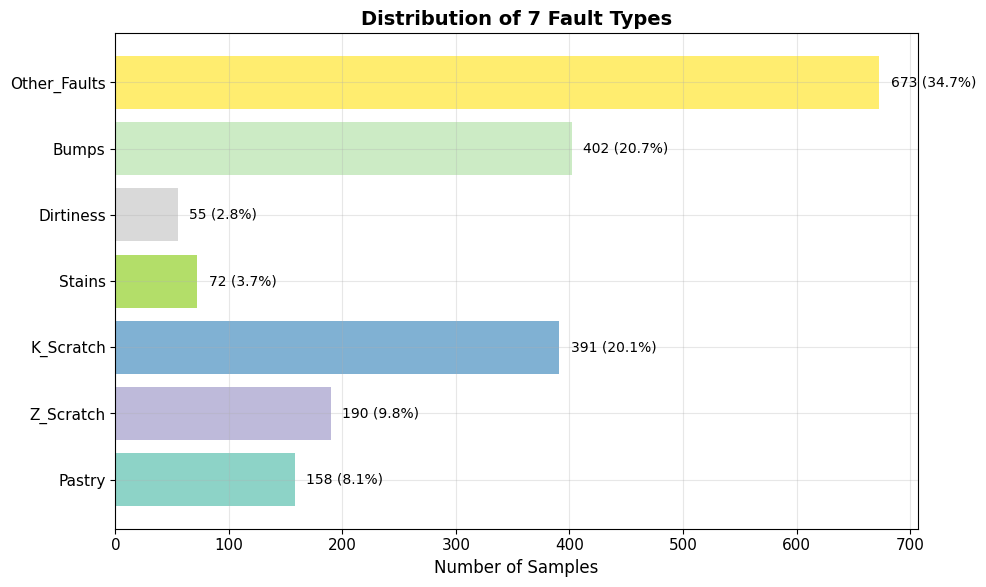

In [38]:
# =============================================================================
# 클래스 분포 시각화
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

counts = [np.sum(y_multi == i) for i in range(len(fault_types))]
colors = plt.cm.Set3(np.linspace(0, 1, len(fault_types)))

bars = ax.barh(fault_types, counts, color=colors)
ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_title('Distribution of 7 Fault Types', fontsize=14, fontweight='bold')

for bar, count in zip(bars, counts):
    pct = count / len(y_multi) * 100
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count} ({pct:.1f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [39]:
# =============================================================================
# 데이터 분할 및 스케일링
# =============================================================================
# stratify를 사용하여 클래스 비율 유지
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_steel, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi  # 다중 클래스에서도 층화 추출 가능
)

# 스케일링
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

print(f"Training samples: {len(X_train_m)}")
print(f"Test samples: {len(X_test_m)}")

Training samples: 1552
Test samples: 389


In [45]:
# =============================================================================
# 다중 클래스 로지스틱 회귀 모델 학습
# =============================================================================
# multi_class='multinomial': Softmax 함수 사용 -> 구 버전 설명이고, 신 버전에서는 따로 명시하지 않아도 됩니다
# solver='lbfgs': 다중 클래스에 적합한 준뉴턴 최적화 알고리즘
# class_weight='balanced': 불균형 클래스 자동 보정

model_multi = LogisticRegression(    
    solver='lbfgs',             # Limited-memory BFGS 최적화
    max_iter=2000,              # 수렴을 위한 충분한 반복
    class_weight='balanced',    # 클래스 불균형 처리
    random_state=42
)

model_multi.fit(X_train_m_scaled, y_train_m)

print("=" * 70)
print("Multinomial Logistic Regression (Softmax) Model Trained")
print("=" * 70)
print(f"\nCoefficient matrix shape: {model_multi.coef_.shape}")
print(f"  -> {model_multi.coef_.shape[0]} classes x {model_multi.coef_.shape[1]} features")

Multinomial Logistic Regression (Softmax) Model Trained

Coefficient matrix shape: (7, 27)
  -> 7 classes x 27 features


In [46]:
# =============================================================================
# 예측 수행
# =============================================================================
# predict(): 가장 높은 확률의 클래스 반환
# predict_proba(): 모든 클래스에 대한 확률 반환 (Softmax 출력)

y_pred_m = model_multi.predict(X_test_m_scaled)
y_proba_m = model_multi.predict_proba(X_test_m_scaled)

print("=" * 60)
print("Prediction Example (First 5 Samples)")
print("=" * 60)

print(f"\n{'Sample':>6} | {'Actual':>15} | {'Predicted':>15} | {'Confidence':>10}")
print("-" * 60)

for i in range(5):
    actual = fault_types[y_test_m[i]]
    predicted = fault_types[y_pred_m[i]]
    confidence = y_proba_m[i].max()
    match = "OK" if y_test_m[i] == y_pred_m[i] else "MISS"
    print(f"{i+1:>6} | {actual:>15} | {predicted:>15} | {confidence:>10.1%} {match}")

print("\n" + "-" * 60)
print("Softmax Probability Distribution (Sample 1):")
print("-" * 60)
for idx, (fault, prob) in enumerate(zip(fault_types, y_proba_m[0])):
    bar = "*" * int(prob * 50)
    print(f"  {fault:15}: {prob:.4f} {bar}")
print(f"\n  Sum of probabilities: {y_proba_m[0].sum():.6f} (should be 1.0)")

Prediction Example (First 5 Samples)

Sample |          Actual |       Predicted | Confidence
------------------------------------------------------------
     1 |           Bumps |           Bumps |      81.8% OK
     2 |       K_Scratch |       K_Scratch |      99.5% OK
     3 |       Z_Scratch |       Z_Scratch |      92.2% OK
     4 |           Bumps |           Bumps |      38.9% OK
     5 |          Stains |          Stains |      93.3% OK

------------------------------------------------------------
Softmax Probability Distribution (Sample 1):
------------------------------------------------------------
  Pastry         : 0.0496 **
  Z_Scratch      : 0.0003 
  K_Scratch      : 0.0006 
  Stains         : 0.0005 
  Dirtiness      : 0.0042 
  Bumps          : 0.8182 ****************************************
  Other_Faults   : 0.1266 ******

  Sum of probabilities: 1.000000 (should be 1.0)


In [47]:
accuracy = accuracy_score(y_test_m, y_pred_m)

print("=" * 70)
print("Multi-class Classification Performance")
print("=" * 70)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy:.1%})")

print("\n" + "=" * 70)
print("Classification Report (Per-class Metrics)")
print("=" * 70)
print(classification_report(y_test_m, y_pred_m, target_names=fault_types, digits=4))

Multi-class Classification Performance

Overall Accuracy: 0.6530 (65.3%)

Classification Report (Per-class Metrics)
              precision    recall  f1-score   support

      Pastry     0.4364    0.7500    0.5517        32
   Z_Scratch     0.6481    0.9211    0.7609        38
   K_Scratch     0.8824    0.9615    0.9202        78
      Stains     0.8667    0.9286    0.8966        14
   Dirtiness     0.2759    0.7273    0.4000        11
       Bumps     0.6023    0.6543    0.6272        81
Other_Faults     0.7302    0.3407    0.4646       135

    accuracy                         0.6530       389
   macro avg     0.6345    0.7548    0.6602       389
weighted avg     0.6939    0.6530    0.6397       389



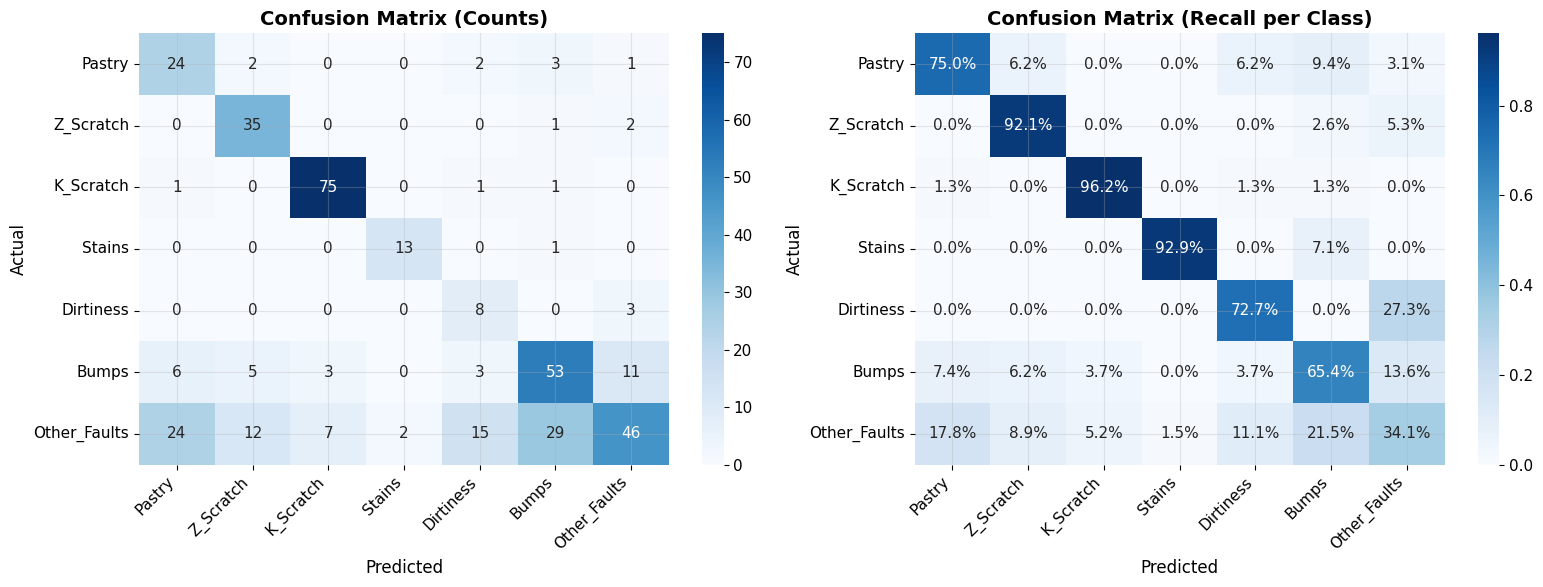

In [51]:
# =============================================================================
# 다중 클래스 혼동 행렬 시각화
# =============================================================================
cm_multi = confusion_matrix(y_test_m, y_pred_m)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 좌측: 개수 기반
ax1 = axes[0]
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=fault_types, yticklabels=fault_types)
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax1.get_yticklabels(), rotation=0)

# 우측: 비율 기반 (행 정규화)
ax2 = axes[1]
cm_normalized = cm_multi.astype('float') / cm_multi.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues', ax=ax2,
            xticklabels=fault_types, yticklabels=fault_types)
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_title('Confusion Matrix (Recall per Class)', fontsize=14, fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Per-class Performance Summary
  Fault Type  Precision   Recall  F1 Score  Support
   K_Scratch   0.882353 0.961538  0.920245       78
      Stains   0.866667 0.928571  0.896552       14
   Z_Scratch   0.648148 0.921053  0.760870       38
       Bumps   0.602273 0.654321  0.627219       81
      Pastry   0.436364 0.750000  0.551724       32
Other_Faults   0.730159 0.340741  0.464646      135
   Dirtiness   0.275862 0.727273  0.400000       11


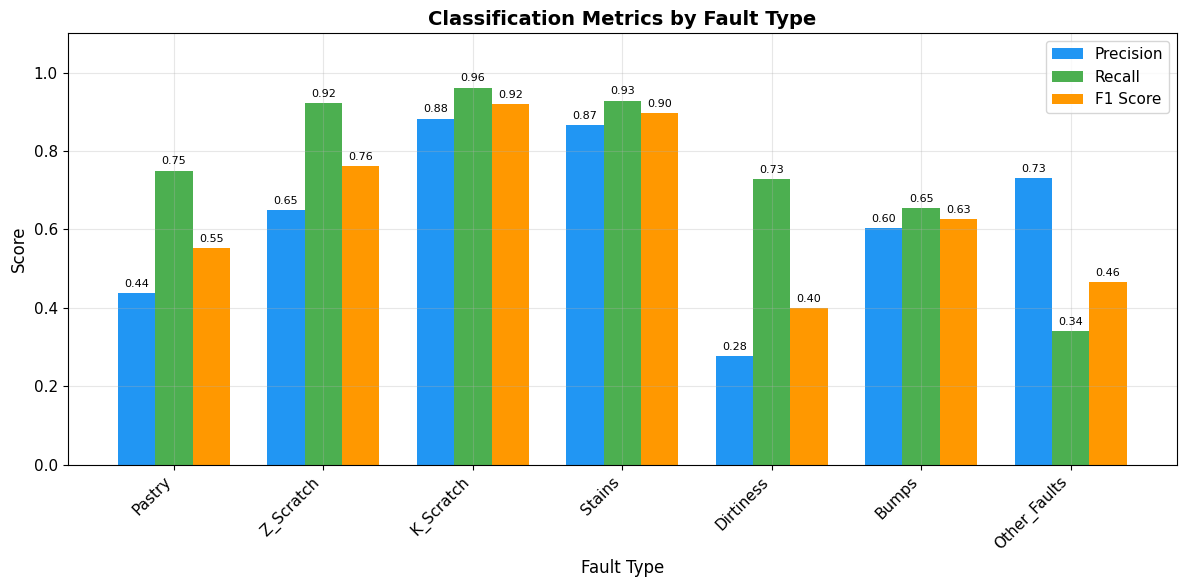

In [52]:
# =============================================================================
# 클래스별 성능 비교 시각화
# =============================================================================
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_m, y_pred_m, average=None
)

# 결과를 DataFrame으로 정리
metrics_df = pd.DataFrame({
    'Fault Type': fault_types,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Support': support
}).sort_values('F1 Score', ascending=False)

print("=" * 70)
print("Per-class Performance Summary")
print("=" * 70)
print(metrics_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(fault_types))
width = 0.25

bars1 = ax.bar(x - width, precision, width, label='Precision', color='#2196F3')
bars2 = ax.bar(x, recall, width, label='Recall', color='#4CAF50')
bars3 = ax.bar(x + width, f1, width, label='F1 Score', color='#FF9800')

ax.set_xlabel('Fault Type', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classification Metrics by Fault Type', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fault_types, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim([0, 1.1])

# 각 막대 위에 값 표시
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Top 10 Important Features (Multi-class)
              feature  mean_abs_coefficient
         Square_Index              0.819758
    Orientation_Index              0.810340
   Length_of_Conveyer              0.789727
        Edges_X_Index              0.760208
Steel_Plate_Thickness              0.719258
          Log_Y_Index              0.651299
Minimum_of_Luminosity              0.645978
Maximum_of_Luminosity              0.633303
          Empty_Index              0.600116
           LogOfAreas              0.588725


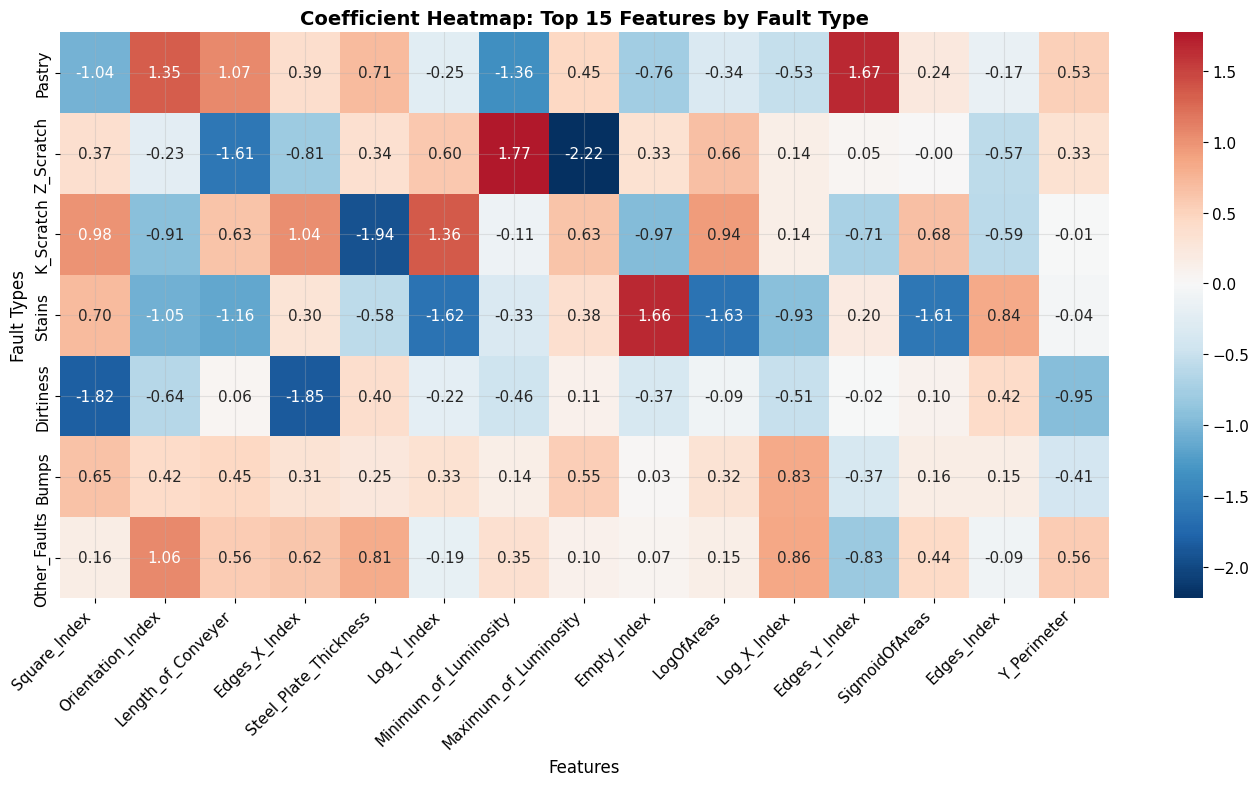

In [53]:
# =============================================================================
# 다중 클래스 특성 중요도 분석
# =============================================================================
# 각 클래스별 계수의 절대값 평균을 특성 중요도로 사용

# 계수 행렬: (7 classes, 27 features)
coef_matrix = model_multi.coef_

# 특성별 평균 절대 계수
mean_abs_coef = np.abs(coef_matrix).mean(axis=0)

# 상위 15개 특성
feature_importance_multi = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_coefficient': mean_abs_coef
}).sort_values('mean_abs_coefficient', ascending=False)

print("=" * 60)
print("Top 10 Important Features (Multi-class)")
print("=" * 60)
print(feature_importance_multi.head(10).to_string(index=False))

# 히트맵으로 클래스별 계수 시각화
fig, ax = plt.subplots(figsize=(14, 8))

# 상위 15개 특성만 선택
top_features_idx = feature_importance_multi.head(15)['feature'].tolist()
top_features_coef = coef_matrix[:, [feature_cols.index(f) for f in top_features_idx]]

sns.heatmap(top_features_coef, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=top_features_idx, yticklabels=fault_types, ax=ax)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Fault Types', fontsize=12)
ax.set_title('Coefficient Heatmap: Top 15 Features by Fault Type', 
             fontsize=14, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

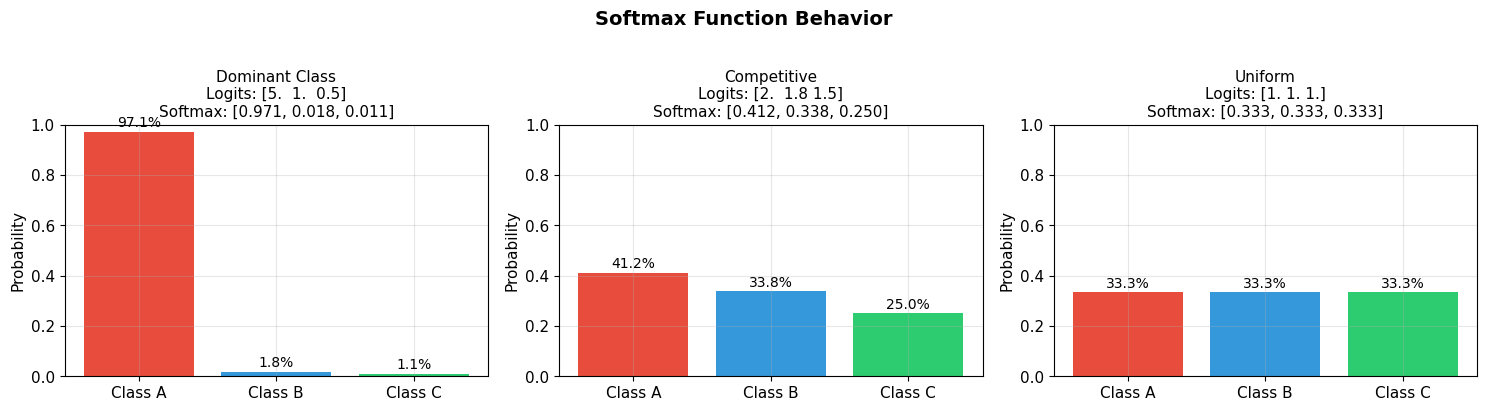

In [54]:
def softmax(z):
    """
    Softmax 함수: logit 벡터를 확률 분포로 변환
    
    수치 안정성을 위해 최댓값을 빼는 트릭 사용:
    softmax(z) = softmax(z - max(z))
    """
    z_stable = z - np.max(z)  # Numerical stability
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z)

# 예시 1: 하나의 클래스가 지배적인 경우
z1 = np.array([5.0, 1.0, 0.5])
p1 = softmax(z1)

# 예시 2: 클래스 간 경쟁이 있는 경우
z2 = np.array([2.0, 1.8, 1.5])
p2 = softmax(z2)

# 예시 3: 균등한 경우
z3 = np.array([1.0, 1.0, 1.0])
p3 = softmax(z3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
classes = ['Class A', 'Class B', 'Class C']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, z, p, title in zip(axes, [z1, z2, z3], [p1, p2, p3], 
                            ['Dominant Class', 'Competitive', 'Uniform']):
    bars = ax.bar(classes, p, color=colors)
    ax.set_ylim([0, 1])
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'{title}\nLogits: {z}\nSoftmax: [{p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f}]', 
                 fontsize=11)
    
    for bar, prob in zip(bars, p):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{prob:.1%}', ha='center', fontsize=10)

plt.suptitle('Softmax Function Behavior', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## A.8 핵심 정리

### 시그모이드 vs 소프트맥스

| 항목 | 시그모이드 (Sigmoid) | 소프트맥스 (Softmax) |
|:-----|:---------------------|:---------------------|
| **수식** | $\sigma(z) = \frac{1}{1 + e^{-z}}$ | $\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$ |
| **입력** | 스칼라 $z$ | 벡터 $\mathbf{z} = [z_1, ..., z_K]$ |
| **출력** | 스칼라 $(0, 1)$ | 벡터, 각 원소 $(0, 1)$, 합 = 1 |
| **클래스 수** | 2 (이진 분류) | K (다중 클래스) |
| **해석** | $P(Y=1)$ | $P(Y=k)$ for each $k$ |
| **손실 함수** | Binary Cross-Entropy | Categorical Cross-Entropy |

### 다중 클래스 분류 체크리스트

```
□ 타겟 변수를 정수 레이블로 변환 (0, 1, 2, ...)
□ 클래스 분포 확인 및 불균형 처리 (class_weight='balanced')
□ 특성 스케일링 적용 (StandardScaler)
□ multi_class='multinomial', solver='lbfgs' 설정
□ 충분한 max_iter 설정 (수렴 확인)
□ 클래스별 Precision, Recall, F1 확인
□ 혼동 행렬로 오분류 패턴 분석
```

### sklearn 코드 요약

```python
# 다중 클래스 로지스틱 회귀 (Softmax)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    multi_class='multinomial',  # Softmax 사용 <- **구버전용, 최신 버전 기준으로는 해당 행을 사용하지 말 것!**
    solver='lbfgs',             # 권장 solver
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)

# 예측
y_pred = model.predict(X_test_scaled)           # 클래스 레이블
y_proba = model.predict_proba(X_test_scaled)    # Softmax 확률 (합 = 1)

# 평가
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=class_names))
```